<a href="https://colab.research.google.com/github/tousifo/ml_notebooks/blob/main/FsQcA_BD_Flood.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# STEP 2: DATASET LOADING AND INITIAL INSPECTION
# Purpose:
# - Load the uploaded dataset
# - Inspect file structure, columns, rows, missing values, dtypes
# - Check whether the dataset contains construct scores or item-level data
# ============================================================

import pandas as pd
import numpy as np
import os
import re
import io
from google.colab import files

# -----------------------------
# 1. Upload dataset
# -----------------------------
print("Please upload the dataset file now. Prefer CSV or Excel.")
uploaded = files.upload()

candidate_files = [
    f for f in uploaded.keys()
    if f.lower().endswith((".csv", ".xlsx", ".xls"))
]

if len(candidate_files) == 0:
    raise ValueError("No CSV or Excel file detected. Please upload the dataset file.")

file_path = candidate_files[0]
print(f"\nLoaded file: {file_path}")

# -----------------------------
# 2. Load dataset safely
# -----------------------------
def load_dataset(path):
    ext = os.path.splitext(path)[1].lower()

    if ext == ".csv":
        encodings = ["utf-8-sig", "utf-8", "latin1"]
        last_error = None

        for enc in encodings:
            try:
                return pd.read_csv(path, encoding=enc), enc
            except Exception as e:
                last_error = e

        raise last_error

    elif ext in [".xlsx", ".xls"]:
        return pd.read_excel(path), "excel"

    else:
        raise ValueError("Unsupported file type. Use CSV, XLSX, or XLS.")

df, encoding_used = load_dataset(file_path)

# Clean column names only by stripping outer spaces
df.columns = df.columns.astype(str).str.strip()

# -----------------------------
# 3. Basic file structure
# -----------------------------
print("\n" + "="*80)
print("FILE STRUCTURE")
print("="*80)
print(f"File name: {file_path}")
print(f"Encoding/source used: {encoding_used}")
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

# -----------------------------
# 4. Column names
# -----------------------------
print("\n" + "="*80)
print("COLUMN NAMES")
print("="*80)

for i, col in enumerate(df.columns, start=1):
    print(f"{i:02d}. {col}")

# -----------------------------
# 5. Data preview
# -----------------------------
print("\n" + "="*80)
print("FIRST 5 ROWS")
print("="*80)
display(df.head())

print("\n" + "="*80)
print("LAST 5 ROWS")
print("="*80)
display(df.tail())

# -----------------------------
# 6. Data types and non-null counts
# -----------------------------
print("\n" + "="*80)
print("DATA TYPES AND NON-NULL COUNTS")
print("="*80)

info_buffer = io.StringIO()
df.info(buf=info_buffer)
print(info_buffer.getvalue())

# -----------------------------
# 7. Missing values
# -----------------------------
print("\n" + "="*80)
print("MISSING VALUES")
print("="*80)

missing_table = pd.DataFrame({
    "column": df.columns,
    "missing_count": df.isna().sum().values,
    "missing_percent": (df.isna().mean().values * 100).round(2)
}).sort_values("missing_count", ascending=False)

display(missing_table)

# -----------------------------
# 8. Duplicate rows
# -----------------------------
print("\n" + "="*80)
print("DUPLICATE ROW CHECK")
print("="*80)

duplicate_count = df.duplicated().sum()
print(f"Number of exact duplicate rows: {duplicate_count}")

# -----------------------------
# 9. Descriptive statistics
# -----------------------------
print("\n" + "="*80)
print("DESCRIPTIVE STATISTICS: NUMERIC VARIABLES")
print("="*80)

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

if len(numeric_cols) > 0:
    display(df[numeric_cols].describe().T)
else:
    print("No numeric columns detected.")

print("\n" + "="*80)
print("DESCRIPTIVE STATISTICS: NON-NUMERIC VARIABLES")
print("="*80)

non_numeric_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

if len(non_numeric_cols) > 0:
    display(df[non_numeric_cols].describe().T)
else:
    print("No non-numeric columns detected.")

# -----------------------------
# 10. Unique values summary
# Useful for Likert-scale data inspection
# -----------------------------
print("\n" + "="*80)
print("UNIQUE VALUE SUMMARY")
print("="*80)

unique_summary = []

for col in df.columns:
    unique_vals = df[col].dropna().unique()
    unique_summary.append({
        "column": col,
        "dtype": str(df[col].dtype),
        "unique_count": df[col].nunique(dropna=True),
        "min_value": df[col].min() if pd.api.types.is_numeric_dtype(df[col]) else None,
        "max_value": df[col].max() if pd.api.types.is_numeric_dtype(df[col]) else None,
        "sample_unique_values": list(unique_vals[:10])
    })

unique_summary_df = pd.DataFrame(unique_summary)
display(unique_summary_df)

# -----------------------------
# 11. Initial Likert-scale validity check
# This does not clean data yet. It only flags possible invalid values.
# Expected Likert range: 1 to 5
# -----------------------------
print("\n" + "="*80)
print("INITIAL LIKERT-SCALE VALUE CHECK")
print("="*80)

if len(numeric_cols) > 0:
    invalid_likert = {}

    for col in numeric_cols:
        invalid_values = sorted(
            df.loc[~df[col].dropna().between(1, 5), col].dropna().unique()
        )
        if len(invalid_values) > 0:
            invalid_likert[col] = invalid_values

    if len(invalid_likert) == 0:
        print("No invalid numeric Likert values detected outside the 1–5 range.")
    else:
        print("Potential invalid Likert values detected:")
        for col, vals in invalid_likert.items():
            print(f"{col}: {vals}")
else:
    print("No numeric columns available for Likert-scale checking.")

# -----------------------------
# 12. Construct-score vs item-level diagnosis
# -----------------------------
print("\n" + "="*80)
print("CONSTRUCT-SCORE VS ITEM-LEVEL DIAGNOSIS")
print("="*80)

required_constructs = ["SS", "SC", "SI", "SN", "TR", "OP", "PE", "RO"]

def normalize_colname(x):
    return re.sub(r"[^A-Z0-9]", "", str(x).upper())

normalized_columns = {col: normalize_colname(col) for col in df.columns}

# Check exact construct score columns
exact_construct_matches = {}

for construct in required_constructs:
    exact_construct_matches[construct] = [
        col for col, norm in normalized_columns.items()
        if norm == construct
    ]

print("\nExact construct-score column check:")
for construct, matches in exact_construct_matches.items():
    print(f"{construct}: {matches if matches else 'NOT FOUND'}")

# Check item-level pattern, e.g., SS1, SS2, SC1, etc.
item_matches = {}

for construct in required_constructs:
    pattern = re.compile(rf"^{construct}\d+$", re.IGNORECASE)
    item_matches[construct] = [
        col for col, norm in normalized_columns.items()
        if pattern.match(norm)
    ]

print("\nLikely item-level column check:")
for construct, matches in item_matches.items():
    print(f"{construct}: {matches if matches else 'NOT FOUND'}")

has_all_construct_scores = all(len(exact_construct_matches[c]) >= 1 for c in required_constructs)
has_all_item_groups = all(len(item_matches[c]) >= 1 for c in required_constructs)

print("\nDataset diagnosis:")
if has_all_construct_scores:
    print("LIKELY STRUCTURE: Construct-score dataset.")
    print("Next step will verify SS, SC, SI, SN, TR, OP, PE, and RO as construct scores.")
elif has_all_item_groups:
    print("LIKELY STRUCTURE: Item-level dataset.")
    print("Next step will calculate construct scores as the mean of each construct's items, after verifying item groups.")
else:
    print("LIKELY STRUCTURE: Mixed or unclear dataset.")
    print("We need to inspect the column names carefully before creating construct scores.")

# -----------------------------
# 13. Save a temporary copy for reproducibility
# -----------------------------
print("\n" + "="*80)
print("TEMPORARY SAVE")
print("="*80)

temp_save_path = "step2_loaded_raw_dataset.csv"
df.to_csv(temp_save_path, index=False)
print(f"Raw loaded dataset saved temporarily as: {temp_save_path}")

print("\nSTEP 2 COMPLETE. Please copy and send the printed output back to ChatGPT.")

Please upload the dataset file now. Prefer CSV or Excel.


Saving Data set (384) for Cumilla - Feni flood Manuscript.csv to Data set (384) for Cumilla - Feni flood Manuscript.csv

Loaded file: Data set (384) for Cumilla - Feni flood Manuscript.csv

FILE STRUCTURE
File name: Data set (384) for Cumilla - Feni flood Manuscript.csv
Encoding/source used: utf-8-sig
Number of rows: 384
Number of columns: 39

COLUMN NAMES
01. SS1
02. SS2
03. SS3
04. SS4
05. SS5
06. SC1
07. SC2
08. SC3
09. SC4
10. SC5
11. SI1
12. SI2
13. SI3
14. SI4
15. SI5
16. SN1
17. SN2
18. SN3
19. SN4
20. SN5
21. TR1
22. TR2
23. TR3
24. TR4
25. TR5
26. OP1
27. OP2
28. OP3
29. OP4
30. PE1
31. PE2
32. PE3
33. PE4
34. PE5
35. RO1
36. RO2
37. RO3
38. RO4
39. RO5

FIRST 5 ROWS


,SS1,SS2,SS3,SS4,SS5,SC1,SC2,SC3,SC4,SC5,...,PE1,PE2,PE3,PE4,PE5,RO1,RO2,RO3,RO4,RO5
0,4,5,3,2,5,2,5,2,3,2,...,5,5,4,5,5,3,4,3,2,3
1,5,2,2,3,2,4,1,4,3,3,...,5,5,5,5,5,4,5,5,5,4
2,3,4,5,5,4,3,4,2,4,4,...,2,3,3,5,4,3,3,4,4,3
3,5,4,4,5,3,5,5,4,5,5,...,1,3,4,4,1,5,5,3,5,4
4,4,5,5,3,4,5,4,4,3,5,...,4,2,2,5,3,3,4,4,4,5



LAST 5 ROWS


,SS1,SS2,SS3,SS4,SS5,SC1,SC2,SC3,SC4,SC5,...,PE1,PE2,PE3,PE4,PE5,RO1,RO2,RO3,RO4,RO5
379,1,1,1,3,2,2,2,4,4,3,...,4,4,1,3,4,1,1,2,2,1
380,2,3,1,1,2,4,5,4,5,4,...,5,2,2,4,4,5,5,4,4,4
381,1,3,3,2,5,2,2,2,3,1,...,3,3,4,3,4,2,1,1,1,2
382,1,1,1,1,1,4,3,3,3,1,...,5,3,4,5,2,1,1,1,1,1
383,5,2,4,3,3,5,5,5,5,5,...,1,1,1,2,1,4,3,4,3,4


...


DUPLICATE ROW CHECK
Number of exact duplicate rows: 0

DESCRIPTIVE STATISTICS: NUMERIC VARIABLES


,count,mean,std,min,25%,50%,75%,max
SS1,384.0,3.0,1.417901,1.0,2.0,3.0,4.0,5.0
SS2,384.0,3.0,1.417901,1.0,2.0,3.0,4.0,5.0
SS3,384.0,3.0,1.417901,1.0,2.0,3.0,4.0,5.0
SS4,384.0,3.0,1.417901,1.0,2.0,3.0,4.0,5.0
SS5,384.0,3.0,1.417901,1.0,2.0,3.0,4.0,5.0
SC1,384.0,3.0,1.417901,1.0,2.0,3.0,4.0,5.0
SC2,384.0,3.0,1.417901,1.0,2.0,3.0,4.0,5.0
SC3,384.0,3.0,1.417901,1.0,2.0,3.0,4.0,5.0
SC4,384.0,3.0,1.417901,1.0,2.0,3.0,4.0,5.0
SC5,384.0,3.0,1.417901,1.0,2.0,3.0,4.0,5.0



DESCRIPTIVE STATISTICS: NON-NUMERIC VARIABLES
No non-numeric columns detected.

UNIQUE VALUE SUMMARY


,column,dtype,unique_count,min_value,max_value,sample_unique_values
0,SS1,int64,5,1,5,"[4, 5, 3, 1, 2]"
1,SS2,int64,5,1,5,"[5, 2, 4, 3, 1]"
2,SS3,int64,5,1,5,"[3, 2, 5, 4, 1]"
3,SS4,int64,5,1,5,"[2, 3, 5, 4, 1]"
4,SS5,int64,5,1,5,"[5, 2, 4, 3, 1]"
5,SC1,int64,5,1,5,"[2, 4, 3, 5, 1]"
6,SC2,int64,5,1,5,"[5, 1, 4, 2, 3]"
7,SC3,int64,5,1,5,"[2, 4, 1, 5, 3]"
8,SC4,int64,5,1,5,"[3, 4, 5, 1, 2]"
9,SC5,int64,5,1,5,"[2, 3, 4, 5, 1]"



INITIAL LIKERT-SCALE VALUE CHECK
No invalid numeric Likert values detected outside the 1–5 range.

CONSTRUCT-SCORE VS ITEM-LEVEL DIAGNOSIS

Exact construct-score column check:
SS: NOT FOUND
SC: NOT FOUND
SI: NOT FOUND
SN: NOT FOUND
TR: NOT FOUND
OP: NOT FOUND
PE: NOT FOUND
RO: NOT FOUND

Likely item-level column check:
SS: ['SS1', 'SS2', 'SS3', 'SS4', 'SS5']
SC: ['SC1', 'SC2', 'SC3', 'SC4', 'SC5']
SI: ['SI1', 'SI2', 'SI3', 'SI4', 'SI5']
SN: ['SN1', 'SN2', 'SN3', 'SN4', 'SN5']
TR: ['TR1', 'TR2', 'TR3', 'TR4', 'TR5']
OP: ['OP1', 'OP2', 'OP3', 'OP4']
PE: ['PE1', 'PE2', 'PE3', 'PE4', 'PE5']
RO: ['RO1', 'RO2', 'RO3', 'RO4', 'RO5']

Dataset diagnosis:
LIKELY STRUCTURE: Item-level dataset.
Next step will calculate construct scores as the mean of each construct's items, after verifying item groups.

TEMPORARY SAVE
Raw loaded dataset saved temporarily as: step2_loaded_raw_dataset.csv

STEP 2 COMPLETE. Please copy and send the printed output back to ChatGPT.


In [2]:
# ============================================================
# STEP 3: CREATE CONSTRUCT SCORES AND CHECK RELIABILITY
# Purpose:
# - Create construct-level scores from item-level Likert variables
# - Check Cronbach's alpha for each construct
# - Inspect construct-level descriptive statistics
# - Save construct-score dataset for fsQCA
# ============================================================

import pandas as pd
import numpy as np
import os
import io

# ------------------------------------------------------------
# 1. Load existing dataframe if available; otherwise reload file
# ------------------------------------------------------------
try:
    df
    print("Using existing dataframe from previous step.")
except NameError:
    print("No dataframe found in memory. Loading from saved Step 2 file.")
    if os.path.exists("step2_loaded_raw_dataset.csv"):
        df = pd.read_csv("step2_loaded_raw_dataset.csv")
    else:
        raise FileNotFoundError(
            "step2_loaded_raw_dataset.csv not found. Please rerun Step 2 first."
        )

df.columns = df.columns.astype(str).str.strip()

# ------------------------------------------------------------
# 2. Define item-to-construct mapping
# ------------------------------------------------------------
construct_items = {
    "SS": ["SS1", "SS2", "SS3", "SS4", "SS5"],
    "SC": ["SC1", "SC2", "SC3", "SC4", "SC5"],
    "SI": ["SI1", "SI2", "SI3", "SI4", "SI5"],
    "SN": ["SN1", "SN2", "SN3", "SN4", "SN5"],
    "TR": ["TR1", "TR2", "TR3", "TR4", "TR5"],
    "OP": ["OP1", "OP2", "OP3", "OP4"],
    "PE": ["PE1", "PE2", "PE3", "PE4", "PE5"],
    "RO": ["RO1", "RO2", "RO3", "RO4", "RO5"]
}

# ------------------------------------------------------------
# 3. Verify all required item columns exist
# ------------------------------------------------------------
print("="*80)
print("ITEM COLUMN VERIFICATION")
print("="*80)

missing_cols = []

for construct, items in construct_items.items():
    construct_missing = [col for col in items if col not in df.columns]
    if construct_missing:
        missing_cols.extend(construct_missing)
        print(f"{construct}: MISSING {construct_missing}")
    else:
        print(f"{construct}: OK -> {items}")

if missing_cols:
    raise ValueError(f"Missing item columns detected: {missing_cols}")

# ------------------------------------------------------------
# 4. Cronbach's alpha function
# ------------------------------------------------------------
def cronbach_alpha(dataframe):
    """
    Calculates Cronbach's alpha for a set of item columns.
    """
    data = dataframe.dropna()
    k = data.shape[1]

    if k < 2:
        return np.nan

    item_variances = data.var(axis=0, ddof=1)
    total_score_variance = data.sum(axis=1).var(ddof=1)

    if total_score_variance == 0:
        return np.nan

    alpha = (k / (k - 1)) * (1 - item_variances.sum() / total_score_variance)
    return alpha

# ------------------------------------------------------------
# 5. Create construct scores and reliability table
# ------------------------------------------------------------
construct_df = pd.DataFrame(index=df.index)
reliability_rows = []

for construct, items in construct_items.items():
    item_data = df[items].copy()

    alpha = cronbach_alpha(item_data)

    construct_df[construct] = item_data.mean(axis=1)

    reliability_rows.append({
        "Construct": construct,
        "Number_of_items": len(items),
        "Items": ", ".join(items),
        "Cronbach_alpha": round(alpha, 4),
        "Alpha_interpretation": (
            "Excellent" if alpha >= 0.90 else
            "Good" if alpha >= 0.80 else
            "Acceptable" if alpha >= 0.70 else
            "Questionable" if alpha >= 0.60 else
            "Poor"
        )
    })

reliability_table = pd.DataFrame(reliability_rows)

print("\n" + "="*80)
print("RELIABILITY TABLE")
print("="*80)
display(reliability_table)

# ------------------------------------------------------------
# 6. Construct-score descriptive statistics
# ------------------------------------------------------------
print("\n" + "="*80)
print("CONSTRUCT-SCORE DESCRIPTIVE STATISTICS")
print("="*80)

construct_desc = construct_df.describe().T
construct_desc["skewness"] = construct_df.skew()
construct_desc["kurtosis"] = construct_df.kurtosis()
display(construct_desc.round(4))

# ------------------------------------------------------------
# 7. Construct-score correlation matrix
# ------------------------------------------------------------
print("\n" + "="*80)
print("CONSTRUCT-SCORE CORRELATION MATRIX")
print("="*80)

construct_corr = construct_df.corr()
display(construct_corr.round(4))

# ------------------------------------------------------------
# 8. Inspect first rows of construct-score dataset
# ------------------------------------------------------------
print("\n" + "="*80)
print("FIRST 10 ROWS OF CONSTRUCT-SCORE DATASET")
print("="*80)
display(construct_df.head(10))

# ------------------------------------------------------------
# 9. Check construct-score range
# ------------------------------------------------------------
print("\n" + "="*80)
print("CONSTRUCT-SCORE RANGE CHECK")
print("="*80)

range_check = pd.DataFrame({
    "Construct": construct_df.columns,
    "Min": construct_df.min().values,
    "Max": construct_df.max().values,
    "Any_below_1": (construct_df < 1).any().values,
    "Any_above_5": (construct_df > 5).any().values
})

display(range_check)

# ------------------------------------------------------------
# 10. Save analysis-ready construct-score dataset
# ------------------------------------------------------------
construct_save_path = "construct_scores_for_fsQCA.csv"
construct_df.to_csv(construct_save_path, index=False)

combined_save_path = "item_and_construct_scores_clean.csv"
combined_df = pd.concat([df, construct_df.add_suffix("_score")], axis=1)
combined_df.to_csv(combined_save_path, index=False)

print("\n" + "="*80)
print("FILES SAVED")
print("="*80)
print(f"Construct-score dataset saved as: {construct_save_path}")
print(f"Combined item + construct-score dataset saved as: {combined_save_path}")

print("\nSTEP 3 COMPLETE. Please send back:")
print("1. Reliability table")
print("2. Construct-score descriptive statistics")
print("3. Construct-score correlation matrix")
print("4. Construct-score range check")

Using existing dataframe from previous step.
ITEM COLUMN VERIFICATION
SS: OK -> ['SS1', 'SS2', 'SS3', 'SS4', 'SS5']
SC: OK -> ['SC1', 'SC2', 'SC3', 'SC4', 'SC5']
SI: OK -> ['SI1', 'SI2', 'SI3', 'SI4', 'SI5']
SN: OK -> ['SN1', 'SN2', 'SN3', 'SN4', 'SN5']
TR: OK -> ['TR1', 'TR2', 'TR3', 'TR4', 'TR5']
OP: OK -> ['OP1', 'OP2', 'OP3', 'OP4']
PE: OK -> ['PE1', 'PE2', 'PE3', 'PE4', 'PE5']
RO: OK -> ['RO1', 'RO2', 'RO3', 'RO4', 'RO5']

RELIABILITY TABLE


,Construct,Number_of_items,Items,Cronbach_alpha,Alpha_interpretation
0,SS,5,"SS1, SS2, SS3, SS4, SS5",0.8495,Good
1,SC,5,"SC1, SC2, SC3, SC4, SC5",0.8628,Good
2,SI,5,"SI1, SI2, SI3, SI4, SI5",0.8425,Good
3,SN,5,"SN1, SN2, SN3, SN4, SN5",0.8808,Good
4,TR,5,"TR1, TR2, TR3, TR4, TR5",0.8569,Good
5,OP,4,"OP1, OP2, OP3, OP4",0.8177,Good
6,PE,5,"PE1, PE2, PE3, PE4, PE5",0.8567,Good
7,RO,5,"RO1, RO2, RO3, RO4, RO5",0.9065,Excellent



CONSTRUCT-SCORE DESCRIPTIVE STATISTICS


,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
SS,384.0,3.0,1.1202,1.0,2.0,3.0,3.8,5.0,0.0467,-1.0730
SC,384.0,3.0,1.1393,1.0,2.0,3.0,4.0,5.0,-0.0106,-1.0338
SI,384.0,3.0,1.1106,1.0,2.2,3.0,3.8,5.0,-0.0394,-0.9578
SN,384.0,3.0,1.1667,1.0,2.0,3.0,4.0,5.0,-0.0048,-1.1385
TR,384.0,3.0,1.1307,1.0,2.0,3.0,4.0,5.0,0.0487,-1.0529
OP,384.0,3.0,1.1400,1.0,2.0,3.0,4.0,5.0,0.0128,-1.0814
PE,384.0,3.0,1.1304,1.0,2.0,3.0,4.0,5.0,-0.0113,-1.1355
RO,384.0,3.0,1.2096,1.0,2.0,3.0,4.0,5.0,-0.0535,-1.1291



CONSTRUCT-SCORE CORRELATION MATRIX


...


FIRST 10 ROWS OF CONSTRUCT-SCORE DATASET


,SS,SC,SI,SN,TR,OP,PE,RO
0,3.8,2.8,1.2,1.6,3.0,1.50,4.8,3.0
1,2.8,3.0,4.6,2.0,2.0,4.50,5.0,4.6
2,4.2,3.4,3.8,4.6,1.2,1.75,3.4,3.4
3,4.2,4.8,2.6,3.6,1.0,4.00,2.6,4.4
4,4.2,4.2,3.4,1.8,2.6,5.00,3.2,4.0
5,3.4,3.2,4.4,4.8,5.0,2.00,3.8,4.4
6,4.8,2.2,3.6,4.2,4.8,1.00,2.4,4.0
7,4.4,4.0,1.0,2.6,2.6,2.50,4.8,4.6
8,3.0,1.2,1.8,1.0,2.8,4.75,3.4,1.6
9,2.6,4.8,1.8,4.8,3.4,5.00,3.8,3.6



CONSTRUCT-SCORE RANGE CHECK


,Construct,Min,Max,Any_below_1,Any_above_5
0,SS,1.0,5.0,False,False
1,SC,1.0,5.0,False,False
2,SI,1.0,5.0,False,False
3,SN,1.0,5.0,False,False
4,TR,1.0,5.0,False,False
5,OP,1.0,5.0,False,False
6,PE,1.0,5.0,False,False
7,RO,1.0,5.0,False,False



FILES SAVED
Construct-score dataset saved as: construct_scores_for_fsQCA.csv
Combined item + construct-score dataset saved as: item_and_construct_scores_clean.csv

STEP 3 COMPLETE. Please send back:
1. Reliability table
2. Construct-score descriptive statistics
3. Construct-score correlation matrix
4. Construct-score range check


Using existing construct_df from previous step.
BASIC CLEANING CHECKS
Rows: 384
Columns: 8
Columns available: ['SS', 'SC', 'SI', 'SN', 'TR', 'OP', 'PE', 'RO']


,Construct,Missing_count,Missing_percent
0,SS,0,0.0
1,SC,0,0.0
2,SI,0,0.0
3,SN,0,0.0
4,TR,0,0.0
5,OP,0,0.0
6,PE,0,0.0
7,RO,0,0.0



Exact duplicate construct-score rows: 0

CONSTRUCT-SCORE VALIDITY CHECK


,Construct,Min,Max,Below_1_count,Above_5_count,Missing_count,Valid_for_Likert_mean
0,SS,1.0,5.0,0,0,0,True
1,SC,1.0,5.0,0,0,0,True
2,SI,1.0,5.0,0,0,0,True
3,SN,1.0,5.0,0,0,0,True
4,TR,1.0,5.0,0,0,0,True
5,OP,1.0,5.0,0,0,0,True
6,PE,1.0,5.0,0,0,0,True
7,RO,1.0,5.0,0,0,0,True



FINAL CONSTRUCT DESCRIPTIVE STATISTICS


...


CALIBRATION-RELEVANT THRESHOLD DISTRIBUTION


,Construct,Below_2,Equal_2,Between_2_and_3,Equal_3,Between_3_and_4,Equal_4,Above_4
0,SS,77,30,75,19,89,11,83
1,SC,78,19,84,23,82,16,82
2,SI,77,15,87,22,91,23,69
3,SN,86,23,67,21,83,24,80
4,TR,72,31,86,16,79,20,80
5,OP,81,23,71,30,82,20,77
6,PE,86,18,71,21,88,17,83
7,RO,90,19,69,18,85,20,83



EMPIRICAL PERCENTILE THRESHOLDS FOR ROBUSTNESS CHECK


,Construct,P10,P25,P50,P75,P90
0,SS,1.60,2.0,3.0,3.8,4.60
1,SC,1.40,2.0,3.0,4.0,4.54
2,SI,1.40,2.2,3.0,3.8,4.60
3,SN,1.40,2.0,3.0,4.0,4.60
4,TR,1.46,2.0,3.0,4.0,4.60
5,OP,1.50,2.0,3.0,4.0,4.75
6,PE,1.40,2.0,3.0,4.0,4.60
7,RO,1.20,2.0,3.0,4.0,4.60



HISTOGRAMS FOR CONSTRUCT DISTRIBUTIONS


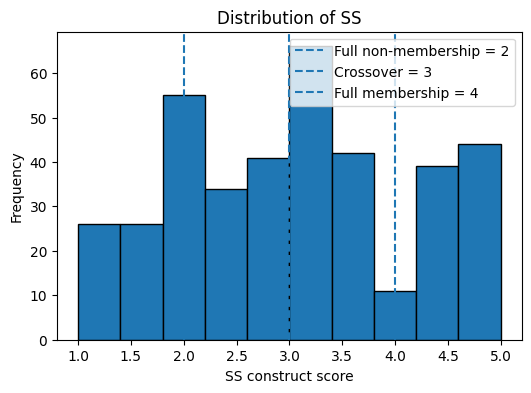

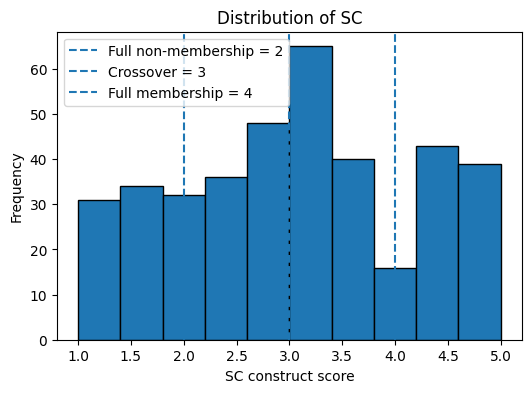

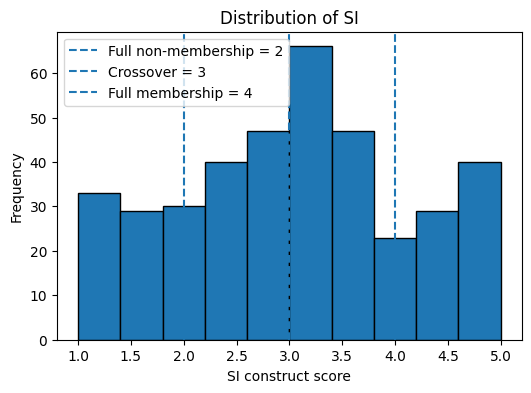

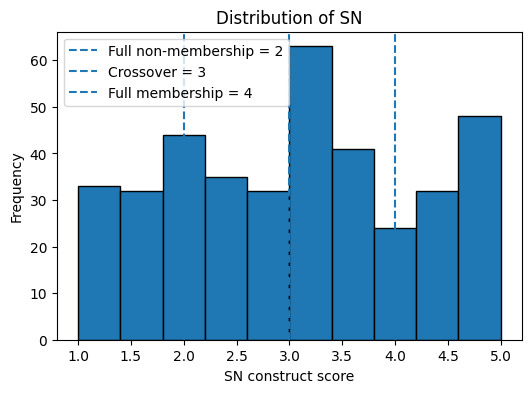

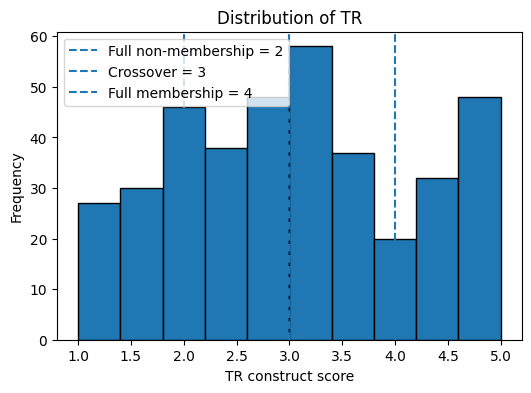

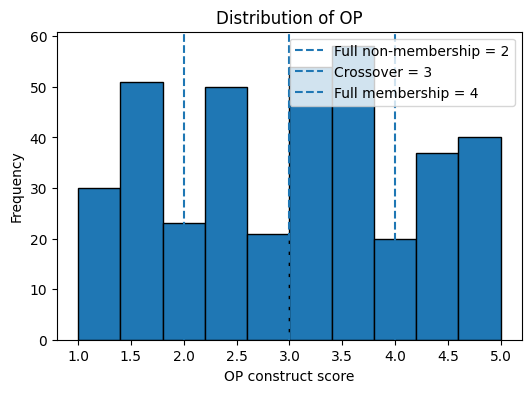

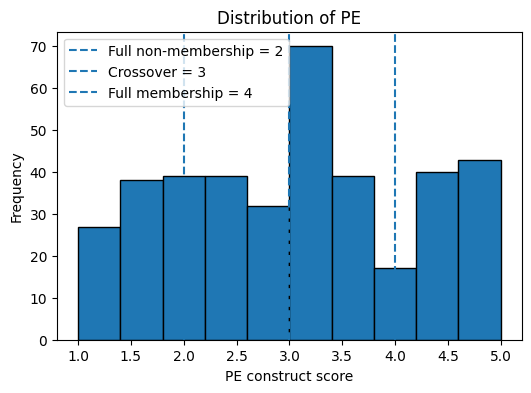

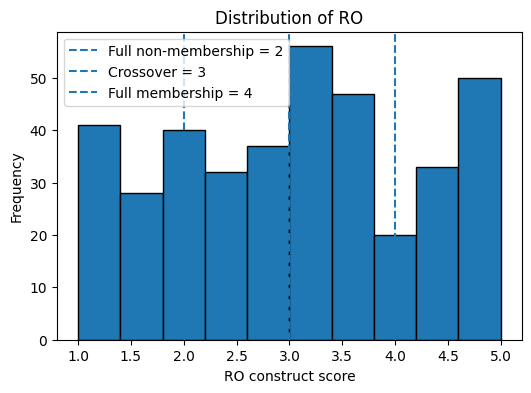


BOXPLOTS FOR CONSTRUCT SCORES


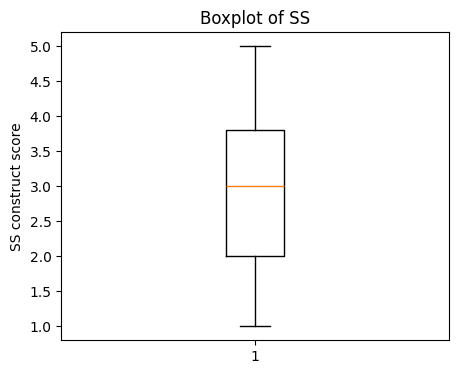

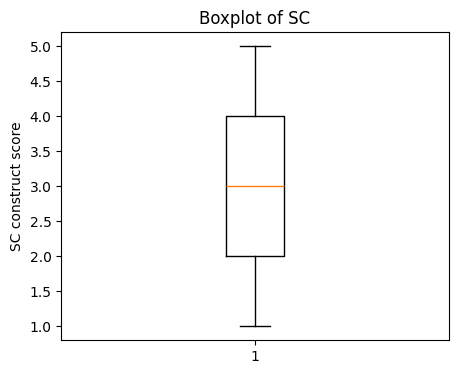

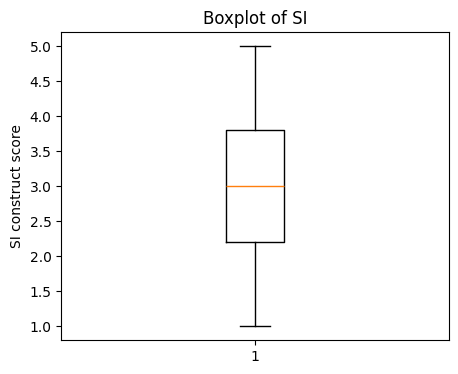

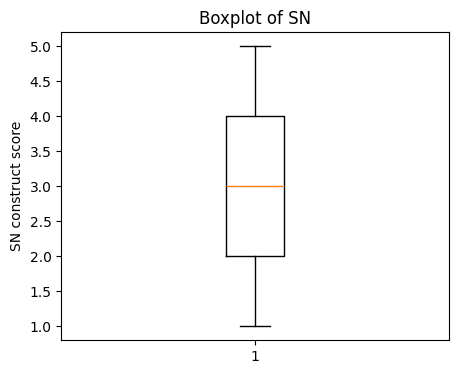

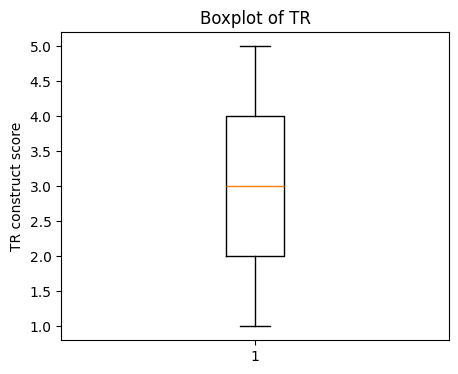

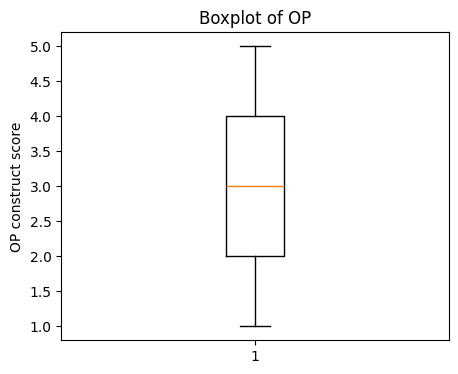

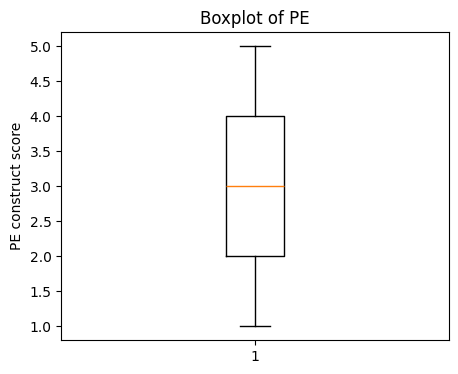

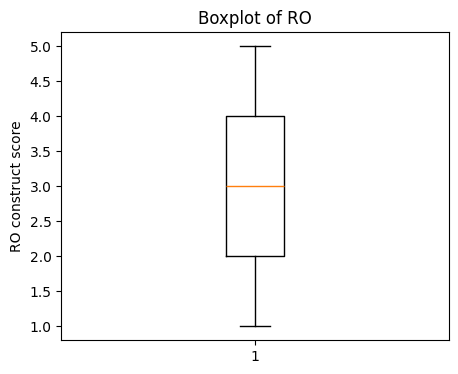


CLEAN DATASET SAVED
Clean construct-score dataset saved as: clean_construct_scores_for_fsQCA.csv

STEP 4 COMPLETE. Please send back:
1. Basic cleaning checks
2. Construct-score validity check
3. Final construct descriptive statistics
4. Calibration-relevant threshold distribution
5. Empirical percentile thresholds
6. Briefly tell me whether the histograms look balanced, skewed, or strange


In [3]:
# ============================================================
# STEP 4: DATA CLEANING AND CONSTRUCT-LEVEL DIAGNOSTICS
# Purpose:
# - Confirm the dataset is clean before fsQCA calibration
# - Check duplicates, missing values, invalid values, construct distributions
# - Inspect whether construct scores are suitable for calibration
# - Save final clean construct-score dataset
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# ------------------------------------------------------------
# 1. Load construct-score dataset if needed
# ------------------------------------------------------------
try:
    construct_df
    print("Using existing construct_df from previous step.")
except NameError:
    if os.path.exists("construct_scores_for_fsQCA.csv"):
        construct_df = pd.read_csv("construct_scores_for_fsQCA.csv")
        print("Loaded construct_scores_for_fsQCA.csv.")
    else:
        raise FileNotFoundError(
            "construct_scores_for_fsQCA.csv not found. Please rerun Step 3 first."
        )

constructs = ["SS", "SC", "SI", "SN", "TR", "OP", "PE", "RO"]

# ------------------------------------------------------------
# 2. Basic cleaning checks
# ------------------------------------------------------------
print("="*80)
print("BASIC CLEANING CHECKS")
print("="*80)

print(f"Rows: {construct_df.shape[0]}")
print(f"Columns: {construct_df.shape[1]}")
print(f"Columns available: {list(construct_df.columns)}")

missing_summary = pd.DataFrame({
    "Construct": construct_df.columns,
    "Missing_count": construct_df.isna().sum().values,
    "Missing_percent": (construct_df.isna().mean().values * 100).round(2)
})

display(missing_summary)

duplicate_count = construct_df.duplicated().sum()
print(f"\nExact duplicate construct-score rows: {duplicate_count}")

# ------------------------------------------------------------
# 3. Construct-score range validity
# ------------------------------------------------------------
print("\n" + "="*80)
print("CONSTRUCT-SCORE VALIDITY CHECK")
print("="*80)

validity_rows = []

for col in constructs:
    below_1 = (construct_df[col] < 1).sum()
    above_5 = (construct_df[col] > 5).sum()
    missing = construct_df[col].isna().sum()

    validity_rows.append({
        "Construct": col,
        "Min": construct_df[col].min(),
        "Max": construct_df[col].max(),
        "Below_1_count": below_1,
        "Above_5_count": above_5,
        "Missing_count": missing,
        "Valid_for_Likert_mean": (below_1 == 0 and above_5 == 0 and missing == 0)
    })

validity_table = pd.DataFrame(validity_rows)
display(validity_table)

# ------------------------------------------------------------
# 4. Descriptive statistics for reporting
# ------------------------------------------------------------
print("\n" + "="*80)
print("FINAL CONSTRUCT DESCRIPTIVE STATISTICS")
print("="*80)

desc_table = construct_df[constructs].describe().T
desc_table["median"] = construct_df[constructs].median()
desc_table["skewness"] = construct_df[constructs].skew()
desc_table["kurtosis"] = construct_df[constructs].kurtosis()

desc_table = desc_table[
    ["count", "mean", "std", "min", "25%", "50%", "75%", "max", "median", "skewness", "kurtosis"]
]

display(desc_table.round(4))

# ------------------------------------------------------------
# 5. Frequency distribution of construct scores
# Because construct scores are means, values may be 1.0, 1.2, 1.4, etc.
# ------------------------------------------------------------
print("\n" + "="*80)
print("CONSTRUCT-SCORE FREQUENCY DISTRIBUTIONS")
print("="*80)

for col in constructs:
    print(f"\n{col} frequency distribution:")
    freq = construct_df[col].value_counts().sort_index()
    freq_percent = (freq / len(construct_df) * 100).round(2)
    freq_table = pd.DataFrame({
        "Score": freq.index,
        "Frequency": freq.values,
        "Percent": freq_percent.values
    })
    display(freq_table)

# ------------------------------------------------------------
# 6. Calibration-relevant distribution check
# Counts below, at, and above theoretical thresholds
# Theoretical thresholds planned:
# full non-membership = 2
# crossover = 3
# full membership = 4
# ------------------------------------------------------------
print("\n" + "="*80)
print("CALIBRATION-RELEVANT THRESHOLD DISTRIBUTION")
print("="*80)

threshold_rows = []

for col in constructs:
    values = construct_df[col]

    threshold_rows.append({
        "Construct": col,
        "Below_2": int((values < 2).sum()),
        "Equal_2": int((values == 2).sum()),
        "Between_2_and_3": int(((values > 2) & (values < 3)).sum()),
        "Equal_3": int((values == 3).sum()),
        "Between_3_and_4": int(((values > 3) & (values < 4)).sum()),
        "Equal_4": int((values == 4).sum()),
        "Above_4": int((values > 4).sum())
    })

threshold_distribution = pd.DataFrame(threshold_rows)
display(threshold_distribution)

# ------------------------------------------------------------
# 7. Percentile thresholds for later robustness calibration
# These are not applied yet.
# ------------------------------------------------------------
print("\n" + "="*80)
print("EMPIRICAL PERCENTILE THRESHOLDS FOR ROBUSTNESS CHECK")
print("="*80)

percentile_rows = []

for col in constructs:
    percentile_rows.append({
        "Construct": col,
        "P10": np.percentile(construct_df[col], 10),
        "P25": np.percentile(construct_df[col], 25),
        "P50": np.percentile(construct_df[col], 50),
        "P75": np.percentile(construct_df[col], 75),
        "P90": np.percentile(construct_df[col], 90)
    })

percentile_table = pd.DataFrame(percentile_rows)
display(percentile_table.round(4))

# ------------------------------------------------------------
# 8. Simple visual inspection: histograms
# ------------------------------------------------------------
print("\n" + "="*80)
print("HISTOGRAMS FOR CONSTRUCT DISTRIBUTIONS")
print("="*80)

for col in constructs:
    plt.figure(figsize=(6, 4))
    plt.hist(construct_df[col], bins=10, edgecolor="black")
    plt.axvline(2, linestyle="--", label="Full non-membership = 2")
    plt.axvline(3, linestyle="--", label="Crossover = 3")
    plt.axvline(4, linestyle="--", label="Full membership = 4")
    plt.title(f"Distribution of {col}")
    plt.xlabel(f"{col} construct score")
    plt.ylabel("Frequency")
    plt.legend()
    plt.show()

# ------------------------------------------------------------
# 9. Boxplots for outlier inspection
# No removal is planned unless values are impossible.
# ------------------------------------------------------------
print("\n" + "="*80)
print("BOXPLOTS FOR CONSTRUCT SCORES")
print("="*80)

for col in constructs:
    plt.figure(figsize=(5, 4))
    plt.boxplot(construct_df[col], vert=True)
    plt.title(f"Boxplot of {col}")
    plt.ylabel(f"{col} construct score")
    plt.show()

# ------------------------------------------------------------
# 10. Save clean dataset
# ------------------------------------------------------------
clean_save_path = "clean_construct_scores_for_fsQCA.csv"
construct_df[constructs].to_csv(clean_save_path, index=False)

print("\n" + "="*80)
print("CLEAN DATASET SAVED")
print("="*80)
print(f"Clean construct-score dataset saved as: {clean_save_path}")

print("\nSTEP 4 COMPLETE. Please send back:")
print("1. Basic cleaning checks")
print("2. Construct-score validity check")
print("3. Final construct descriptive statistics")
print("4. Calibration-relevant threshold distribution")
print("5. Empirical percentile thresholds")
print("6. Briefly tell me whether the histograms look balanced, skewed, or strange")

In [4]:
# ============================================================
# STEP 5: FUZZY-SET CALIBRATION
# Purpose:
# - Calibrate construct scores into fuzzy-set membership scores
# - Main calibration uses theoretical Likert-based anchors:
#   full non-membership = 2
#   crossover = 3
#   full membership = 4
# - Save calibrated dataset for necessity and sufficiency analysis
# ============================================================

import pandas as pd
import numpy as np
import os

# ------------------------------------------------------------
# 1. Load clean construct-score dataset
# ------------------------------------------------------------
try:
    construct_df
    print("Using existing construct_df from previous steps.")
except NameError:
    if os.path.exists("clean_construct_scores_for_fsQCA.csv"):
        construct_df = pd.read_csv("clean_construct_scores_for_fsQCA.csv")
        print("Loaded clean_construct_scores_for_fsQCA.csv.")
    elif os.path.exists("construct_scores_for_fsQCA.csv"):
        construct_df = pd.read_csv("construct_scores_for_fsQCA.csv")
        print("Loaded construct_scores_for_fsQCA.csv.")
    else:
        raise FileNotFoundError(
            "No construct-score dataset found. Please rerun Step 3 or Step 4."
        )

constructs = ["SS", "SC", "SI", "SN", "TR", "OP", "PE", "RO"]

# ------------------------------------------------------------
# 2. Define direct fuzzy-set calibration function
# ------------------------------------------------------------
def calibrate_direct(x, full_out=2, crossover=3, full_in=4, eps=1e-6):
    """
    Direct fuzzy-set calibration using a logistic transformation.

    Anchors:
    - full_out: value corresponding approximately to fuzzy membership 0.05
    - crossover: value corresponding to fuzzy membership 0.50
    - full_in: value corresponding approximately to fuzzy membership 0.95

    Exact 0.50 scores are adjusted slightly to avoid fsQCA ambiguity.
    """
    x = np.asarray(x, dtype=float)

    # Logit value for 0.95 membership
    log_odds_95 = np.log(0.95 / 0.05)

    # Scaling factor: ensures full_in is about 0.95
    k = log_odds_95 / (full_in - crossover)

    calibrated = 1 / (1 + np.exp(-k * (x - crossover)))

    # Avoid exact crossover ambiguity at 0.50
    calibrated = np.where(np.isclose(calibrated, 0.5), 0.5 + eps, calibrated)

    return calibrated

# ------------------------------------------------------------
# 3. Apply theoretical Likert-based calibration
# ------------------------------------------------------------
calibrated_df = construct_df.copy()

calibration_anchors = []

for col in constructs:
    calibrated_df[f"{col}_fz"] = calibrate_direct(
        calibrated_df[col],
        full_out=2,
        crossover=3,
        full_in=4
    )

    calibration_anchors.append({
        "Condition": col,
        "Full_non_membership": 2,
        "Crossover": 3,
        "Full_membership": 4,
        "Calibrated_variable": f"{col}_fz"
    })

calibration_table = pd.DataFrame(calibration_anchors)

print("="*80)
print("CALIBRATION ANCHORS")
print("="*80)
display(calibration_table)

# ------------------------------------------------------------
# 4. Preview calibrated fuzzy-set scores
# ------------------------------------------------------------
fz_cols = [f"{col}_fz" for col in constructs]

print("\n" + "="*80)
print("FIRST 10 ROWS: RAW AND CALIBRATED SCORES")
print("="*80)

display(calibrated_df[constructs + fz_cols].head(10).round(4))

# ------------------------------------------------------------
# 5. Descriptive statistics for calibrated scores
# ------------------------------------------------------------
print("\n" + "="*80)
print("DESCRIPTIVE STATISTICS: CALIBRATED FUZZY-SET SCORES")
print("="*80)

fz_desc = calibrated_df[fz_cols].describe().T
fz_desc["median"] = calibrated_df[fz_cols].median()
fz_desc["skewness"] = calibrated_df[fz_cols].skew()
fz_desc["kurtosis"] = calibrated_df[fz_cols].kurtosis()

display(fz_desc.round(4))

# ------------------------------------------------------------
# 6. Membership distribution check
# ------------------------------------------------------------
print("\n" + "="*80)
print("FUZZY MEMBERSHIP DISTRIBUTION CHECK")
print("="*80)

membership_rows = []

for col in constructs:
    fz = calibrated_df[f"{col}_fz"]

    membership_rows.append({
        "Condition": f"{col}_fz",
        "Mostly_out_<0.50": int((fz < 0.50).sum()),
        "Crossover_exact_0.50": int(np.isclose(fz, 0.50).sum()),
        "Mostly_in_>0.50": int((fz > 0.50).sum()),
        "High_membership_>=0.80": int((fz >= 0.80).sum()),
        "Low_membership_<=0.20": int((fz <= 0.20).sum()),
        "Min": fz.min(),
        "Max": fz.max()
    })

membership_table = pd.DataFrame(membership_rows)
display(membership_table.round(4))

# ------------------------------------------------------------
# 7. Check calibrated RO outcome distribution
# ------------------------------------------------------------
print("\n" + "="*80)
print("OUTCOME DISTRIBUTION: RO_fz")
print("="*80)

ro_fz = calibrated_df["RO_fz"]

print(f"Cases mostly OUT of high RO set, RO_fz < 0.50: {(ro_fz < 0.50).sum()}")
print(f"Cases mostly IN high RO set, RO_fz > 0.50: {(ro_fz > 0.50).sum()}")
print(f"Cases with strong high RO membership, RO_fz >= 0.80: {(ro_fz >= 0.80).sum()}")
print(f"Cases with strong low RO membership, RO_fz <= 0.20: {(ro_fz <= 0.20).sum()}")

# ------------------------------------------------------------
# 8. Save calibrated dataset
# ------------------------------------------------------------
calibrated_save_path = "calibrated_fuzzyset_data_theoretical_234.csv"
calibrated_df.to_csv(calibrated_save_path, index=False)

print("\n" + "="*80)
print("CALIBRATED DATASET SAVED")
print("="*80)
print(f"Saved calibrated fuzzy-set dataset as: {calibrated_save_path}")

print("\nSTEP 5 COMPLETE. Please send back:")
print("1. Calibration anchors table")
print("2. First 10 rows of raw and calibrated scores")
print("3. Descriptive statistics for calibrated fuzzy-set scores")
print("4. Fuzzy membership distribution check")
print("5. Outcome distribution for RO_fz")

Using existing construct_df from previous steps.
CALIBRATION ANCHORS


,Condition,Full_non_membership,Crossover,Full_membership,Calibrated_variable
0,SS,2,3,4,SS_fz
1,SC,2,3,4,SC_fz
2,SI,2,3,4,SI_fz
3,SN,2,3,4,SN_fz
4,TR,2,3,4,TR_fz
5,OP,2,3,4,OP_fz
6,PE,2,3,4,PE_fz
7,RO,2,3,4,RO_fz



FIRST 10 ROWS: RAW AND CALIBRATED SCORES


,SS,SC,SI,SN,TR,OP,PE,RO,SS_fz,SC_fz,SI_fz,SN_fz,TR_fz,OP_fz,PE_fz,RO_fz
0,3.8,2.8,1.2,1.6,3.0,1.50,4.8,3.0,0.9134,0.3569,0.0050,0.0160,0.5000,0.0119,0.9950,0.5000
1,2.8,3.0,4.6,2.0,2.0,4.50,5.0,4.6,0.3569,0.5000,0.9911,0.0500,0.0500,0.9881,0.9972,0.9911
2,4.2,3.4,3.8,4.6,1.2,1.75,3.4,3.4,0.9716,0.7645,0.9134,0.9911,0.0050,0.0246,0.7645,0.7645
3,4.2,4.8,2.6,3.6,1.0,4.00,2.6,4.4,0.9716,0.9950,0.2355,0.8540,0.0028,0.9500,0.2355,0.9840
4,4.2,4.2,3.4,1.8,2.6,5.00,3.2,4.0,0.9716,0.9716,0.7645,0.0284,0.2355,0.9972,0.6431,0.9500
5,3.4,3.2,4.4,4.8,5.0,2.00,3.8,4.4,0.7645,0.6431,0.9840,0.9950,0.9972,0.0500,0.9134,0.9840
6,4.8,2.2,3.6,4.2,4.8,1.00,2.4,4.0,0.9950,0.0866,0.8540,0.9716,0.9950,0.0028,0.1460,0.9500
7,4.4,4.0,1.0,2.6,2.6,2.50,4.8,4.6,0.9840,0.9500,0.0028,0.2355,0.2355,0.1866,0.9950,0.9911
8,3.0,1.2,1.8,1.0,2.8,4.75,3.4,1.6,0.5000,0.0050,0.0284,0.0028,0.3569,0.9942,0.7645,0.0160
9,2.6,4.8,1.8,4.8,3.4,5.00,3.8,3.6,0.2355,0.9950,0.0284,0.9950,0.7645,0.9972,0.9134,0.8540



DESCRIPTIVE STATISTICS: CALIBRATED FUZZY-SET SCORES


,count,mean,std,min,25%,50%,75%,max,median,skewness,kurtosis
SS_fz,384.0,0.4969,0.4009,0.0028,0.0500,0.5,0.9134,0.9972,0.5,0.0044,-1.7360
SC_fz,384.0,0.5016,0.3977,0.0028,0.0500,0.5,0.9500,0.9972,0.5,-0.0091,-1.7010
SI_fz,384.0,0.5051,0.3933,0.0028,0.0866,0.5,0.9134,0.9972,0.5,-0.0305,-1.6984
SN_fz,384.0,0.5033,0.4064,0.0028,0.0500,0.5,0.9500,0.9972,0.5,-0.0337,-1.7465
TR_fz,384.0,0.4932,0.4004,0.0028,0.0500,0.5,0.9500,0.9972,0.5,0.0458,-1.7285
OP_fz,384.0,0.5002,0.4020,0.0028,0.0500,0.5,0.9500,0.9972,0.5,-0.0133,-1.7313
PE_fz,384.0,0.5042,0.4029,0.0028,0.0500,0.5,0.9500,0.9972,0.5,-0.0375,-1.7354
RO_fz,384.0,0.5090,0.4095,0.0028,0.0500,0.5,0.9500,0.9972,0.5,-0.0608,-1.7536



FUZZY MEMBERSHIP DISTRIBUTION CHECK


,Condition,Mostly_out_<0.50,Crossover_exact_0.50,Mostly_in_>0.50,High_membership_>=0.80,Low_membership_<=0.20,Min,Max
0,SS_fz,182,19,202,136,141,0.0028,0.9972
1,SC_fz,181,23,203,138,133,0.0028,0.9972
2,SI_fz,179,22,205,139,132,0.0028,0.9972
3,SN_fz,176,21,208,145,144,0.0028,0.9972
4,TR_fz,189,16,195,137,141,0.0028,0.9972
5,OP_fz,175,30,209,155,154,0.0028,0.9972
6,PE_fz,175,21,209,139,143,0.0028,0.9972
7,RO_fz,178,18,206,150,141,0.0028,0.9972



OUTCOME DISTRIBUTION: RO_fz
Cases mostly OUT of high RO set, RO_fz < 0.50: 178
Cases mostly IN high RO set, RO_fz > 0.50: 206
Cases with strong high RO membership, RO_fz >= 0.80: 150
Cases with strong low RO membership, RO_fz <= 0.20: 141

CALIBRATED DATASET SAVED
Saved calibrated fuzzy-set dataset as: calibrated_fuzzyset_data_theoretical_234.csv

STEP 5 COMPLETE. Please send back:
1. Calibration anchors table
2. First 10 rows of raw and calibrated scores
3. Descriptive statistics for calibrated fuzzy-set scores
4. Fuzzy membership distribution check
5. Outcome distribution for RO_fz


In [5]:
# ============================================================
# STEP 6: NECESSITY ANALYSIS FOR HIGH RELIEF OPERATION
# Purpose:
# - Test whether any single condition is necessary for high RO
# - Test both presence and absence of each condition
# - Use consistency threshold = 0.90
# ============================================================

import pandas as pd
import numpy as np
import os

# ------------------------------------------------------------
# 1. Load calibrated fuzzy-set dataset
# ------------------------------------------------------------
try:
    calibrated_df
    print("Using existing calibrated_df from previous step.")
except NameError:
    if os.path.exists("calibrated_fuzzyset_data_theoretical_234.csv"):
        calibrated_df = pd.read_csv("calibrated_fuzzyset_data_theoretical_234.csv")
        print("Loaded calibrated_fuzzyset_data_theoretical_234.csv.")
    else:
        raise FileNotFoundError(
            "calibrated_fuzzyset_data_theoretical_234.csv not found. Please rerun Step 5."
        )

# ------------------------------------------------------------
# 2. Define conditions and outcome
# ------------------------------------------------------------
conditions = ["SS_fz", "SC_fz", "SI_fz", "SN_fz", "TR_fz", "OP_fz", "PE_fz"]
outcome = "RO_fz"

# ------------------------------------------------------------
# 3. Necessity formulas
# For X necessary for Y:
# consistency = sum(min(X, Y)) / sum(Y)
# coverage    = sum(min(X, Y)) / sum(X)
# ------------------------------------------------------------
def necessity_consistency(condition, outcome):
    return np.minimum(condition, outcome).sum() / outcome.sum()

def necessity_coverage(condition, outcome):
    return np.minimum(condition, outcome).sum() / condition.sum()

# ------------------------------------------------------------
# 4. Run necessity analysis for presence and absence
# ------------------------------------------------------------
necessity_rows = []

Y = calibrated_df[outcome]

for cond in conditions:
    X_present = calibrated_df[cond]
    X_absent = 1 - calibrated_df[cond]

    # Presence of condition
    cons_present = necessity_consistency(X_present, Y)
    cov_present = necessity_coverage(X_present, Y)

    necessity_rows.append({
        "Condition": cond,
        "Condition_type": "Presence",
        "Consistency": cons_present,
        "Coverage": cov_present,
        "Necessary_at_0.90": cons_present >= 0.90
    })

    # Absence of condition
    cons_absent = necessity_consistency(X_absent, Y)
    cov_absent = necessity_coverage(X_absent, Y)

    necessity_rows.append({
        "Condition": "~" + cond,
        "Condition_type": "Absence",
        "Consistency": cons_absent,
        "Coverage": cov_absent,
        "Necessary_at_0.90": cons_absent >= 0.90
    })

necessity_table = pd.DataFrame(necessity_rows)

# ------------------------------------------------------------
# 5. Sort by consistency
# ------------------------------------------------------------
necessity_table = necessity_table.sort_values(
    by="Consistency",
    ascending=False
).reset_index(drop=True)

print("="*80)
print("NECESSITY ANALYSIS FOR HIGH RO")
print("="*80)

display(necessity_table.round(4))

# ------------------------------------------------------------
# 6. Show only potential necessary conditions
# ------------------------------------------------------------
print("\n" + "="*80)
print("POTENTIALLY NECESSARY CONDITIONS, CONSISTENCY >= 0.90")
print("="*80)

necessary_conditions = necessity_table[necessity_table["Consistency"] >= 0.90]

if necessary_conditions.empty:
    print("No single condition reaches the 0.90 necessity consistency threshold.")
else:
    display(necessary_conditions.round(4))

# ------------------------------------------------------------
# 7. Save necessity table
# ------------------------------------------------------------
necessity_save_path = "necessity_analysis_high_RO.csv"
necessity_table.to_csv(necessity_save_path, index=False)

print("\n" + "="*80)
print("FILE SAVED")
print("="*80)
print(f"Necessity analysis table saved as: {necessity_save_path}")

print("\nSTEP 6 COMPLETE. Please send back:")
print("1. Full necessity analysis table")
print("2. Potentially necessary conditions section")

Using existing calibrated_df from previous step.
NECESSITY ANALYSIS FOR HIGH RO


,Condition,Condition_type,Consistency,Coverage,Necessary_at_0.90
0,SC_fz,Presence,0.6316,0.6410,False
1,SI_fz,Presence,0.6309,0.6358,False
2,SN_fz,Presence,0.6161,0.6231,False
3,TR_fz,Presence,0.5780,0.5965,False
4,PE_fz,Presence,0.5732,0.5787,False
5,SS_fz,Presence,0.5690,0.5828,False
6,OP_fz,Presence,0.5632,0.5731,False
7,~OP_fz,Absence,0.5271,0.5368,False
8,~PE_fz,Absence,0.5260,0.5400,False
9,~TR_fz,Absence,0.5216,0.5239,False



POTENTIALLY NECESSARY CONDITIONS, CONSISTENCY >= 0.90
No single condition reaches the 0.90 necessity consistency threshold.

FILE SAVED
Necessity analysis table saved as: necessity_analysis_high_RO.csv

STEP 6 COMPLETE. Please send back:
1. Full necessity analysis table
2. Potentially necessary conditions section


In [9]:
# ============================================================
# STEP 7D: CALIBRATION ROBUSTNESS DIAGNOSTIC
# Purpose:
# - Test whether fsQCA findings depend on one calibration choice
# - Compare theoretical and empirical calibration anchors
# - Evaluate full model vs reduced bonding-bridging model
# - Do NOT treat this as result-hunting; treat it as robustness testing
# ============================================================

import pandas as pd
import numpy as np
import itertools
import os

# ------------------------------------------------------------
# 1. Load clean construct-score dataset
# ------------------------------------------------------------
try:
    construct_df
    print("Using existing construct_df.")
except NameError:
    if os.path.exists("clean_construct_scores_for_fsQCA.csv"):
        construct_df = pd.read_csv("clean_construct_scores_for_fsQCA.csv")
        print("Loaded clean_construct_scores_for_fsQCA.csv.")
    elif os.path.exists("construct_scores_for_fsQCA.csv"):
        construct_df = pd.read_csv("construct_scores_for_fsQCA.csv")
        print("Loaded construct_scores_for_fsQCA.csv.")
    else:
        raise FileNotFoundError(
            "No construct-score dataset found. Please rerun Step 3 or Step 4."
        )

constructs = ["SS", "SC", "SI", "SN", "TR", "OP", "PE", "RO"]

# ------------------------------------------------------------
# 2. Direct calibration function
# ------------------------------------------------------------
def calibrate_direct(x, full_out, crossover, full_in, eps=1e-6):
    """
    Direct fuzzy-set calibration using logistic transformation.
    full_out approximates membership 0.05.
    crossover approximates membership 0.50.
    full_in approximates membership 0.95.
    """
    x = np.asarray(x, dtype=float)

    if full_in == crossover:
        raise ValueError("full_in cannot equal crossover.")

    k = np.log(0.95 / 0.05) / (full_in - crossover)
    calibrated = 1 / (1 + np.exp(-k * (x - crossover)))

    # Avoid exact 0.50 ambiguity
    calibrated = np.where(np.isclose(calibrated, 0.5), 0.5 + eps, calibrated)

    return calibrated

# ------------------------------------------------------------
# 3. Define calibration schemes
# ------------------------------------------------------------
def get_percentile_anchors(df, variables, lower_p, cross_p, upper_p):
    anchors = {}
    for v in variables:
        anchors[v] = {
            "full_out": np.percentile(df[v], lower_p),
            "crossover": np.percentile(df[v], cross_p),
            "full_in": np.percentile(df[v], upper_p)
        }
    return anchors

# Main theoretical anchors
anchors_theoretical_234 = {
    v: {"full_out": 2, "crossover": 3, "full_in": 4}
    for v in constructs
}

# Empirical percentile anchors
anchors_p25_p50_p75 = get_percentile_anchors(construct_df, constructs, 25, 50, 75)
anchors_p10_p50_p90 = get_percentile_anchors(construct_df, constructs, 10, 50, 90)

# Slightly stricter and slightly lenient theory-based alternatives
anchors_strict_2534 = {
    v: {"full_out": 2.5, "crossover": 3, "full_in": 4}
    for v in constructs
}

anchors_lenient_2335 = {
    v: {"full_out": 2, "crossover": 3, "full_in": 3.5}
    for v in constructs
}

calibration_schemes = {
    "theoretical_2_3_4": anchors_theoretical_234,
    "empirical_P25_P50_P75": anchors_p25_p50_p75,
    "empirical_P10_P50_P90": anchors_p10_p50_p90,
    "strict_2.5_3_4": anchors_strict_2534,
    "lenient_2_3_3.5": anchors_lenient_2335
}

# ------------------------------------------------------------
# 4. Helper functions for truth-table diagnostics
# ------------------------------------------------------------
def configuration_membership(dataframe, conditions, binary_pattern):
    memberships = []

    for cond, bit in zip(conditions, binary_pattern):
        if bit == 1:
            memberships.append(dataframe[cond].values)
        else:
            memberships.append(1 - dataframe[cond].values)

    return np.min(np.vstack(memberships), axis=0)

def fuzzy_consistency(config_membership, outcome_membership):
    denominator = config_membership.sum()
    if denominator == 0:
        return np.nan
    return np.minimum(config_membership, outcome_membership).sum() / denominator

def fuzzy_coverage(config_membership, outcome_membership):
    denominator = outcome_membership.sum()
    if denominator == 0:
        return np.nan
    return np.minimum(config_membership, outcome_membership).sum() / denominator

def pri_consistency(config_membership, outcome_membership):
    not_outcome = 1 - outcome_membership

    numerator = (
        np.minimum(config_membership, outcome_membership).sum()
        - np.minimum.reduce([config_membership, outcome_membership, not_outcome]).sum()
    )

    denominator = (
        np.minimum(config_membership, outcome_membership).sum()
        + np.minimum(config_membership, not_outcome).sum()
        - np.minimum.reduce([config_membership, outcome_membership, not_outcome]).sum()
    )

    if denominator == 0:
        return np.nan

    return numerator / denominator

def build_truth_table(calibrated_data, condition_cols, outcome_col):
    Y = calibrated_data[outcome_col].values

    binary_condition_names = [c.replace("_fz", "") for c in condition_cols]

    binary_data = pd.DataFrame(index=calibrated_data.index)
    for cond in condition_cols:
        binary_data[cond.replace("_fz", "")] = (calibrated_data[cond] > 0.50).astype(int)

    pattern_series = binary_data[binary_condition_names].astype(str).agg("".join, axis=1)
    pattern_counts = pattern_series.value_counts().to_dict()

    truth_rows = []

    for pattern in itertools.product([0, 1], repeat=len(condition_cols)):
        pattern_string = "".join(map(str, pattern))
        case_count = pattern_counts.get(pattern_string, 0)

        config_mem = configuration_membership(calibrated_data, condition_cols, pattern)

        row = {
            "configuration": pattern_string,
            "case_count": case_count,
            "consistency": fuzzy_consistency(config_mem, Y),
            "PRI_consistency": pri_consistency(config_mem, Y),
            "raw_coverage": fuzzy_coverage(config_mem, Y)
        }

        for cond_name, bit in zip(binary_condition_names, pattern):
            row[cond_name] = bit

        truth_rows.append(row)

    return pd.DataFrame(truth_rows)

# ------------------------------------------------------------
# 5. Apply each calibration and evaluate truth tables
# ------------------------------------------------------------
full_conditions_base = ["SS", "SC", "SI", "SN", "TR", "OP", "PE"]
reduced_conditions_base = ["SS", "SC", "SI", "SN"]

summary_rows = []
all_truth_tables = {}

# Main inclusion rules
# Full model: n >= 3 because 7 conditions create 128 rows
# Reduced model: n >= 10 because only 16 rows exist
rules = {
    "full": {
        "conditions": full_conditions_base,
        "frequency_cutoff": 3
    },
    "reduced": {
        "conditions": reduced_conditions_base,
        "frequency_cutoff": 10
    }
}

consistency_cutoffs = [0.75, 0.80, 0.85]
pri_cutoffs = [0.40, 0.50, 0.60, 0.65]

anchor_rows = []

for scheme_name, anchors in calibration_schemes.items():

    # Create calibrated copy
    cal_df = construct_df.copy()

    for v in constructs:
        full_out = anchors[v]["full_out"]
        crossover = anchors[v]["crossover"]
        full_in = anchors[v]["full_in"]

        cal_df[f"{v}_fz"] = calibrate_direct(
            cal_df[v],
            full_out=full_out,
            crossover=crossover,
            full_in=full_in
        )

        anchor_rows.append({
            "scheme": scheme_name,
            "variable": v,
            "full_out": full_out,
            "crossover": crossover,
            "full_in": full_in
        })

    outcome_col = "RO_fz"

    for model_name, model_rule in rules.items():
        condition_cols = [f"{v}_fz" for v in model_rule["conditions"]]
        n_cut = model_rule["frequency_cutoff"]

        tt = build_truth_table(cal_df, condition_cols, outcome_col)
        all_truth_tables[(scheme_name, model_name)] = tt

        for cons_cut in consistency_cutoffs:
            for pri_cut in pri_cutoffs:
                included = tt[
                    (tt["case_count"] >= n_cut) &
                    (tt["consistency"] >= cons_cut) &
                    (tt["PRI_consistency"] >= pri_cut)
                ]

                summary_rows.append({
                    "calibration_scheme": scheme_name,
                    "model": model_name,
                    "frequency_cutoff": n_cut,
                    "consistency_cutoff": cons_cut,
                    "PRI_cutoff": pri_cut,
                    "included_configurations": len(included),
                    "total_cases_in_included_rows": int(included["case_count"].sum()) if len(included) > 0 else 0,
                    "max_consistency": tt["consistency"].max(),
                    "max_PRI": tt["PRI_consistency"].max(),
                    "mean_consistency_included": included["consistency"].mean() if len(included) > 0 else np.nan,
                    "mean_PRI_included": included["PRI_consistency"].mean() if len(included) > 0 else np.nan,
                    "mean_coverage_included": included["raw_coverage"].mean() if len(included) > 0 else np.nan
                })

anchor_table = pd.DataFrame(anchor_rows)
robustness_summary = pd.DataFrame(summary_rows)

# ------------------------------------------------------------
# 6. Print calibration anchors
# ------------------------------------------------------------
print("="*80)
print("CALIBRATION ANCHOR TABLE")
print("="*80)
display(anchor_table.round(4))

# ------------------------------------------------------------
# 7. Print compact robustness summary
# Focus on main rule: consistency >= 0.80, PRI >= 0.50
# ------------------------------------------------------------
print("\n" + "="*80)
print("MAIN ROBUSTNESS SUMMARY: CONSISTENCY >= 0.80 AND PRI >= 0.50")
print("="*80)

main_summary = robustness_summary[
    (robustness_summary["consistency_cutoff"] == 0.80) &
    (robustness_summary["PRI_cutoff"] == 0.50)
].sort_values(
    by=["model", "included_configurations", "total_cases_in_included_rows"],
    ascending=[True, False, False]
)

display(main_summary.round(4))

# ------------------------------------------------------------
# 8. Print strict robustness summary
# Focus on consistency >= 0.80, PRI >= 0.65
# ------------------------------------------------------------
print("\n" + "="*80)
print("STRICT ROBUSTNESS SUMMARY: CONSISTENCY >= 0.80 AND PRI >= 0.65")
print("="*80)

strict_summary = robustness_summary[
    (robustness_summary["consistency_cutoff"] == 0.80) &
    (robustness_summary["PRI_cutoff"] == 0.65)
].sort_values(
    by=["model", "included_configurations", "total_cases_in_included_rows"],
    ascending=[True, False, False]
)

display(strict_summary.round(4))

# ------------------------------------------------------------
# 9. Show included reduced-model configurations under each calibration
# using consistency >= 0.80 and PRI >= 0.50
# ------------------------------------------------------------
print("\n" + "="*80)
print("REDUCED-MODEL INCLUDED CONFIGURATIONS BY CALIBRATION")
print("="*80)

for scheme_name in calibration_schemes.keys():
    tt = all_truth_tables[(scheme_name, "reduced")]
    included = tt[
        (tt["case_count"] >= 10) &
        (tt["consistency"] >= 0.80) &
        (tt["PRI_consistency"] >= 0.50)
    ].sort_values(
        by=["consistency", "PRI_consistency", "case_count"],
        ascending=[False, False, False]
    )

    print(f"\n--- {scheme_name} ---")
    if included.empty:
        print("No reduced-model configuration included.")
    else:
        display(included.round(4))

# ------------------------------------------------------------
# 10. Show full-model included configurations under each calibration
# using consistency >= 0.80 and PRI >= 0.50
# ------------------------------------------------------------
print("\n" + "="*80)
print("FULL-MODEL INCLUDED CONFIGURATIONS BY CALIBRATION")
print("="*80)

for scheme_name in calibration_schemes.keys():
    tt = all_truth_tables[(scheme_name, "full")]
    included = tt[
        (tt["case_count"] >= 3) &
        (tt["consistency"] >= 0.80) &
        (tt["PRI_consistency"] >= 0.50)
    ].sort_values(
        by=["consistency", "PRI_consistency", "case_count"],
        ascending=[False, False, False]
    )

    print(f"\n--- {scheme_name} ---")
    if included.empty:
        print("No full-model configuration included.")
    else:
        display(included.round(4))

# ------------------------------------------------------------
# 11. Save outputs
# ------------------------------------------------------------
anchor_table.to_csv("calibration_robustness_anchor_table.csv", index=False)
robustness_summary.to_csv("calibration_robustness_summary.csv", index=False)
main_summary.to_csv("calibration_robustness_main_summary.csv", index=False)
strict_summary.to_csv("calibration_robustness_strict_summary.csv", index=False)

# Save all truth tables separately
for (scheme_name, model_name), tt in all_truth_tables.items():
    filename = f"truth_table_{model_name}_{scheme_name}.csv"
    tt.to_csv(filename, index=False)

print("\n" + "="*80)
print("FILES SAVED")
print("="*80)
print("Saved: calibration_robustness_anchor_table.csv")
print("Saved: calibration_robustness_summary.csv")
print("Saved: calibration_robustness_main_summary.csv")
print("Saved: calibration_robustness_strict_summary.csv")
print("Saved individual truth tables for all calibration schemes.")

print("\nSTEP 7D COMPLETE. Please send back:")
print("1. Calibration anchor table")
print("2. Main robustness summary")
print("3. Strict robustness summary")
print("4. Reduced-model included configurations by calibration")
print("5. Full-model included configurations by calibration")

Using existing construct_df.
CALIBRATION ANCHOR TABLE


,scheme,variable,full_out,crossover,full_in
0,theoretical_2_3_4,SS,2.00,3.0,4.00
1,theoretical_2_3_4,SC,2.00,3.0,4.00
2,theoretical_2_3_4,SI,2.00,3.0,4.00
3,theoretical_2_3_4,SN,2.00,3.0,4.00
4,theoretical_2_3_4,TR,2.00,3.0,4.00
5,theoretical_2_3_4,OP,2.00,3.0,4.00
6,theoretical_2_3_4,PE,2.00,3.0,4.00
7,theoretical_2_3_4,RO,2.00,3.0,4.00
8,empirical_P25_P50_P75,SS,2.00,3.0,3.80
9,empirical_P25_P50_P75,SC,2.00,3.0,4.00



MAIN ROBUSTNESS SUMMARY: CONSISTENCY >= 0.80 AND PRI >= 0.50


,calibration_scheme,model,frequency_cutoff,consistency_cutoff,PRI_cutoff,included_configurations,total_cases_in_included_rows,max_consistency,max_PRI,mean_consistency_included,mean_PRI_included,mean_coverage_included
101,lenient_2_3_3.5,full,3,0.8,0.5,14,56,0.9657,0.8336,0.8736,0.6889,0.0246
5,theoretical_2_3_4,full,3,0.8,0.5,0,0,0.9066,0.4140,NaN,NaN,NaN
29,empirical_P25_P50_P75,full,3,0.8,0.5,0,0,0.9201,0.4350,NaN,NaN,NaN
53,empirical_P10_P50_P90,full,3,0.8,0.5,0,0,0.9270,0.2258,NaN,NaN,NaN
77,strict_2.5_3_4,full,3,0.8,0.5,0,0,0.9066,0.4140,NaN,NaN,NaN
17,theoretical_2_3_4,reduced,10,0.8,0.5,1,24,0.8664,0.5255,0.8664,0.5255,0.1559
41,empirical_P25_P50_P75,reduced,10,0.8,0.5,1,24,0.8711,0.5462,0.8711,0.5462,0.1432
89,strict_2.5_3_4,reduced,10,0.8,0.5,1,24,0.8664,0.5255,0.8664,0.5255,0.1559
113,lenient_2_3_3.5,reduced,10,0.8,0.5,1,24,0.8503,0.7343,0.8503,0.7343,0.0998
65,empirical_P10_P50_P90,reduced,10,0.8,0.5,0,0,0.8997,0.3336,NaN,NaN,NaN



STRICT ROBUSTNESS SUMMARY: CONSISTENCY >= 0.80 AND PRI >= 0.65


...


--- lenient_2_3_3.5 ---


,configuration,case_count,consistency,PRI_consistency,raw_coverage,SS,SC,SI,SN
15,1111,24,0.8503,0.7343,0.0998,1,1,1,1



FULL-MODEL INCLUDED CONFIGURATIONS BY CALIBRATION

--- theoretical_2_3_4 ---
No full-model configuration included.

--- empirical_P25_P50_P75 ---
No full-model configuration included.

--- empirical_P10_P50_P90 ---
No full-model configuration included.

--- strict_2.5_3_4 ---
No full-model configuration included.

--- lenient_2_3_3.5 ---


,configuration,case_count,consistency,PRI_consistency,raw_coverage,SS,SC,SI,SN,TR,OP,PE
94,1011110,5,0.9657,0.8336,0.0261,1,0,1,1,1,1,0
122,1111010,3,0.9293,0.7995,0.0190,1,1,1,1,0,1,0
124,1111100,6,0.9245,0.7094,0.0293,1,1,1,1,1,0,0
55,0110111,3,0.9148,0.7287,0.0232,0,1,1,0,1,1,1
115,1110011,3,0.8988,0.7326,0.0201,1,1,1,0,0,1,1
111,1101111,3,0.8866,0.7565,0.0162,1,1,0,1,1,1,1
117,1110101,4,0.8726,0.5331,0.0234,1,1,1,0,1,0,1
127,1111111,3,0.8512,0.6601,0.0176,1,1,1,1,1,1,1
125,1111101,6,0.8488,0.6707,0.0305,1,1,1,1,1,0,1
46,0101110,3,0.8470,0.6386,0.0203,0,1,0,1,1,1,0



FILES SAVED
Saved: calibration_robustness_anchor_table.csv
Saved: calibration_robustness_summary.csv
Saved: calibration_robustness_main_summary.csv
Saved: calibration_robustness_strict_summary.csv
Saved individual truth tables for all calibration schemes.

STEP 7D COMPLETE. Please send back:
1. Calibration anchor table
2. Main robustness summary
3. Strict robustness summary
4. Reduced-model included configurations by calibration
5. Full-model included configurations by calibration


In [10]:
# ============================================================
# STEP 8: FINAL HIGH-RO SOLUTION METRICS + ROBUSTNESS TABLE
# Purpose:
# - Compute final sufficiency metrics for the main reduced fsQCA solution
# - Main solution:
#   SS_fz * SC_fz * SI_fz * SN_fz -> RO_fz
# - Main calibration:
#   theoretical 2–3–4
# - Also prepare compact robustness table for reporting
# ============================================================

import pandas as pd
import numpy as np
import os

# ------------------------------------------------------------
# 1. Load calibrated theoretical 2-3-4 dataset
# ------------------------------------------------------------
try:
    calibrated_df
    print("Using existing calibrated_df.")
except NameError:
    if os.path.exists("calibrated_fuzzyset_data_theoretical_234.csv"):
        calibrated_df = pd.read_csv("calibrated_fuzzyset_data_theoretical_234.csv")
        print("Loaded calibrated_fuzzyset_data_theoretical_234.csv.")
    else:
        raise FileNotFoundError(
            "calibrated_fuzzyset_data_theoretical_234.csv not found. Please rerun Step 5."
        )

# ------------------------------------------------------------
# 2. Define outcome and solution path
# ------------------------------------------------------------
Y = calibrated_df["RO_fz"].values

solution_conditions = {
    "SS_fz": 1,
    "SC_fz": 1,
    "SI_fz": 1,
    "SN_fz": 1
}

# ------------------------------------------------------------
# 3. Helper functions
# ------------------------------------------------------------
def path_membership(dataframe, path_dict):
    memberships = []

    for cond, status in path_dict.items():
        if status == 1:
            memberships.append(dataframe[cond].values)
        elif status == 0:
            memberships.append(1 - dataframe[cond].values)
        else:
            raise ValueError("Condition status must be 1 or 0.")

    return np.min(np.vstack(memberships), axis=0)

def sufficiency_consistency(path_mem, outcome_mem):
    denominator = path_mem.sum()
    if denominator == 0:
        return np.nan
    return np.minimum(path_mem, outcome_mem).sum() / denominator

def sufficiency_coverage(path_mem, outcome_mem):
    denominator = outcome_mem.sum()
    if denominator == 0:
        return np.nan
    return np.minimum(path_mem, outcome_mem).sum() / denominator

def pri_consistency(path_mem, outcome_mem):
    not_outcome = 1 - outcome_mem

    numerator = (
        np.minimum(path_mem, outcome_mem).sum()
        - np.minimum.reduce([path_mem, outcome_mem, not_outcome]).sum()
    )

    denominator = (
        np.minimum(path_mem, outcome_mem).sum()
        + np.minimum(path_mem, not_outcome).sum()
        - np.minimum.reduce([path_mem, outcome_mem, not_outcome]).sum()
    )

    if denominator == 0:
        return np.nan

    return numerator / denominator

# ------------------------------------------------------------
# 4. Compute final solution metrics
# ------------------------------------------------------------
solution_mem = path_membership(calibrated_df, solution_conditions)

solution_consistency = sufficiency_consistency(solution_mem, Y)
solution_coverage = sufficiency_coverage(solution_mem, Y)
solution_pri = pri_consistency(solution_mem, Y)

crisp_case_count = int(
    (
        (calibrated_df["SS_fz"] > 0.50) &
        (calibrated_df["SC_fz"] > 0.50) &
        (calibrated_df["SI_fz"] > 0.50) &
        (calibrated_df["SN_fz"] > 0.50)
    ).sum()
)

solution_table = pd.DataFrame([{
    "Solution_path": "R1: Bonding–bridging convergence",
    "SS": "●",
    "SC": "●",
    "SI": "●",
    "SN": "●",
    "TR": "",
    "OP": "",
    "PE": "",
    "Crisp_case_count": crisp_case_count,
    "Raw_coverage": solution_coverage,
    "Unique_coverage": solution_coverage,
    "Consistency": solution_consistency,
    "PRI_consistency": solution_pri
}])

overall_solution_table = pd.DataFrame([{
    "Solution": "Reduced bonding–bridging model",
    "Calibration": "Theoretical 2–3–4",
    "Number_of_paths": 1,
    "Overall_solution_coverage": solution_coverage,
    "Overall_solution_consistency": solution_consistency,
    "Overall_solution_PRI": solution_pri
}])

print("="*80)
print("FINAL HIGH-RO SUFFICIENCY SOLUTION TABLE")
print("="*80)
display(solution_table.round(4))

print("\n" + "="*80)
print("OVERALL SOLUTION METRICS")
print("="*80)
display(overall_solution_table.round(4))

# ------------------------------------------------------------
# 5. Robustness summary table based on your Step 7D results
# Manually encoded from confirmed output
# ------------------------------------------------------------
robustness_table = pd.DataFrame([
    {
        "Calibration": "Theoretical 2–3–4",
        "Model": "Reduced",
        "Configuration": "SS*SC*SI*SN",
        "Included": "Yes",
        "Consistency": 0.8664,
        "PRI_consistency": 0.5255,
        "Raw_coverage": 0.1559,
        "Interpretation": "Main solution"
    },
    {
        "Calibration": "Empirical P25–P50–P75",
        "Model": "Reduced",
        "Configuration": "SS*SC*SI*SN",
        "Included": "Yes",
        "Consistency": 0.8711,
        "PRI_consistency": 0.5462,
        "Raw_coverage": 0.1432,
        "Interpretation": "Supports main solution"
    },
    {
        "Calibration": "Strict 2.5–3–4",
        "Model": "Reduced",
        "Configuration": "SS*SC*SI*SN",
        "Included": "Yes",
        "Consistency": 0.8664,
        "PRI_consistency": 0.5255,
        "Raw_coverage": 0.1559,
        "Interpretation": "Supports main solution"
    },
    {
        "Calibration": "Lenient 2–3–3.5",
        "Model": "Reduced",
        "Configuration": "SS*SC*SI*SN",
        "Included": "Yes",
        "Consistency": 0.8503,
        "PRI_consistency": 0.7343,
        "Raw_coverage": 0.0998,
        "Interpretation": "Supports main solution under permissive calibration"
    },
    {
        "Calibration": "Empirical P10–P50–P90",
        "Model": "Reduced",
        "Configuration": "SS*SC*SI*SN",
        "Included": "No",
        "Consistency": np.nan,
        "PRI_consistency": np.nan,
        "Raw_coverage": np.nan,
        "Interpretation": "Main solution not retained under highly conservative calibration"
    },
    {
        "Calibration": "Theoretical 2–3–4",
        "Model": "Full",
        "Configuration": "Any",
        "Included": "No",
        "Consistency": np.nan,
        "PRI_consistency": np.nan,
        "Raw_coverage": np.nan,
        "Interpretation": "Full model not supported"
    },
    {
        "Calibration": "Empirical P25–P50–P75",
        "Model": "Full",
        "Configuration": "Any",
        "Included": "No",
        "Consistency": np.nan,
        "PRI_consistency": np.nan,
        "Raw_coverage": np.nan,
        "Interpretation": "Full model not supported"
    },
    {
        "Calibration": "Strict 2.5–3–4",
        "Model": "Full",
        "Configuration": "Any",
        "Included": "No",
        "Consistency": np.nan,
        "PRI_consistency": np.nan,
        "Raw_coverage": np.nan,
        "Interpretation": "Full model not supported"
    }
])

print("\n" + "="*80)
print("COMPACT ROBUSTNESS TABLE")
print("="*80)
display(robustness_table)

# ------------------------------------------------------------
# 6. Save tables
# ------------------------------------------------------------
solution_table.to_csv("final_high_RO_reduced_solution_table.csv", index=False)
overall_solution_table.to_csv("final_high_RO_overall_solution_metrics.csv", index=False)
robustness_table.to_csv("final_fsQCA_calibration_robustness_table.csv", index=False)

print("\n" + "="*80)
print("FILES SAVED")
print("="*80)
print("Saved: final_high_RO_reduced_solution_table.csv")
print("Saved: final_high_RO_overall_solution_metrics.csv")
print("Saved: final_fsQCA_calibration_robustness_table.csv")

print("\nSTEP 8 COMPLETE. Please send back:")
print("1. Final high-RO sufficiency solution table")
print("2. Overall solution metrics")
print("3. Compact robustness table")

Using existing calibrated_df.
FINAL HIGH-RO SUFFICIENCY SOLUTION TABLE


,Solution_path,SS,SC,SI,SN,TR,OP,PE,Crisp_case_count,Raw_coverage,Unique_coverage,Consistency,PRI_consistency
0,R1: Bonding–bridging convergence,●,●,●,●,,,,24,0.1559,0.1559,0.8664,0.5255



OVERALL SOLUTION METRICS


,Solution,Calibration,Number_of_paths,Overall_solution_coverage,Overall_solution_consistency,Overall_solution_PRI
0,Reduced bonding–bridging model,Theoretical 2–3–4,1,0.1559,0.8664,0.5255



COMPACT ROBUSTNESS TABLE


,Calibration,Model,Configuration,Included,Consistency,PRI_consistency,Raw_coverage,Interpretation
0,Theoretical 2–3–4,Reduced,SS*SC*SI*SN,Yes,0.8664,0.5255,0.1559,Main solution
1,Empirical P25–P50–P75,Reduced,SS*SC*SI*SN,Yes,0.8711,0.5462,0.1432,Supports main solution
2,Strict 2.5–3–4,Reduced,SS*SC*SI*SN,Yes,0.8664,0.5255,0.1559,Supports main solution
3,Lenient 2–3–3.5,Reduced,SS*SC*SI*SN,Yes,0.8503,0.7343,0.0998,Supports main solution under permissive calibr...
4,Empirical P10–P50–P90,Reduced,SS*SC*SI*SN,No,NaN,NaN,NaN,Main solution not retained under highly conser...
5,Theoretical 2–3–4,Full,Any,No,NaN,NaN,NaN,Full model not supported
6,Empirical P25–P50–P75,Full,Any,No,NaN,NaN,NaN,Full model not supported
7,Strict 2.5–3–4,Full,Any,No,NaN,NaN,NaN,Full model not supported



FILES SAVED
Saved: final_high_RO_reduced_solution_table.csv
Saved: final_high_RO_overall_solution_metrics.csv
Saved: final_fsQCA_calibration_robustness_table.csv

STEP 8 COMPLETE. Please send back:
1. Final high-RO sufficiency solution table
2. Overall solution metrics
3. Compact robustness table


In [11]:
# ============================================================
# STEP 9: ABSENCE-OF-OUTCOME ANALYSIS FOR LOW / NOT-HIGH RO
# Purpose:
# - Because fsQCA is asymmetric, analyze configurations leading to not-high RO
# - Create not_RO_fz = 1 - RO_fz
# - Test reduced bonding-bridging model:
#   SS_fz, SC_fz, SI_fz, SN_fz
# - Produce truth table and solution metrics for not_RO_fz
# ============================================================

import pandas as pd
import numpy as np
import itertools
import os

# ------------------------------------------------------------
# 1. Load calibrated theoretical 2-3-4 dataset
# ------------------------------------------------------------
try:
    calibrated_df
    print("Using existing calibrated_df.")
except NameError:
    if os.path.exists("calibrated_fuzzyset_data_theoretical_234.csv"):
        calibrated_df = pd.read_csv("calibrated_fuzzyset_data_theoretical_234.csv")
        print("Loaded calibrated_fuzzyset_data_theoretical_234.csv.")
    else:
        raise FileNotFoundError(
            "calibrated_fuzzyset_data_theoretical_234.csv not found. Please rerun Step 5."
        )

# ------------------------------------------------------------
# 2. Create absence-of-outcome variable
# ------------------------------------------------------------
calibrated_df["not_RO_fz"] = 1 - calibrated_df["RO_fz"]

conditions_reduced = ["SS_fz", "SC_fz", "SI_fz", "SN_fz"]
outcome_absent = "not_RO_fz"

Y = calibrated_df[outcome_absent].values

# ------------------------------------------------------------
# 3. Helper functions
# ------------------------------------------------------------
def configuration_membership(dataframe, conditions, binary_pattern):
    memberships = []

    for cond, bit in zip(conditions, binary_pattern):
        if bit == 1:
            memberships.append(dataframe[cond].values)
        else:
            memberships.append(1 - dataframe[cond].values)

    return np.min(np.vstack(memberships), axis=0)

def fuzzy_consistency(config_membership, outcome_membership):
    denominator = config_membership.sum()
    if denominator == 0:
        return np.nan
    return np.minimum(config_membership, outcome_membership).sum() / denominator

def fuzzy_coverage(config_membership, outcome_membership):
    denominator = outcome_membership.sum()
    if denominator == 0:
        return np.nan
    return np.minimum(config_membership, outcome_membership).sum() / denominator

def pri_consistency(config_membership, outcome_membership):
    not_outcome = 1 - outcome_membership

    numerator = (
        np.minimum(config_membership, outcome_membership).sum()
        - np.minimum.reduce([config_membership, outcome_membership, not_outcome]).sum()
    )

    denominator = (
        np.minimum(config_membership, outcome_membership).sum()
        + np.minimum(config_membership, not_outcome).sum()
        - np.minimum.reduce([config_membership, outcome_membership, not_outcome]).sum()
    )

    if denominator == 0:
        return np.nan

    return numerator / denominator

# ------------------------------------------------------------
# 4. Build reduced truth table for not-high RO
# ------------------------------------------------------------
binary_data = pd.DataFrame(index=calibrated_df.index)

for cond in conditions_reduced:
    binary_data[cond.replace("_fz", "")] = (calibrated_df[cond] > 0.50).astype(int)

binary_condition_names = [cond.replace("_fz", "") for cond in conditions_reduced]

pattern_series = binary_data[binary_condition_names].astype(str).agg("".join, axis=1)
pattern_counts = pattern_series.value_counts().to_dict()

truth_rows = []

for pattern in itertools.product([0, 1], repeat=len(conditions_reduced)):
    pattern_string = "".join(map(str, pattern))
    case_count = pattern_counts.get(pattern_string, 0)

    config_mem = configuration_membership(calibrated_df, conditions_reduced, pattern)

    row = {
        "configuration": pattern_string,
        "case_count": case_count,
        "consistency": fuzzy_consistency(config_mem, Y),
        "PRI_consistency": pri_consistency(config_mem, Y),
        "raw_coverage": fuzzy_coverage(config_mem, Y)
    }

    for cond_name, bit in zip(binary_condition_names, pattern):
        row[cond_name] = bit

    truth_rows.append(row)

truth_table_not_RO = pd.DataFrame(truth_rows)

ordered_cols = (
    ["configuration"] +
    binary_condition_names +
    ["case_count", "consistency", "PRI_consistency", "raw_coverage"]
)

truth_table_not_RO = truth_table_not_RO[ordered_cols]

truth_table_not_RO = truth_table_not_RO.sort_values(
    by=["consistency", "PRI_consistency", "case_count"],
    ascending=[False, False, False]
).reset_index(drop=True)

print("="*80)
print("REDUCED-MODEL TRUTH TABLE: NOT-HIGH RO")
print("="*80)
display(truth_table_not_RO.round(4))

# ------------------------------------------------------------
# 5. Inclusion rule for not-high RO
# ------------------------------------------------------------
frequency_cutoff = 10
consistency_cutoff = 0.80
pri_cutoff = 0.50

included_not_RO = truth_table_not_RO[
    (truth_table_not_RO["case_count"] >= frequency_cutoff) &
    (truth_table_not_RO["consistency"] >= consistency_cutoff) &
    (truth_table_not_RO["PRI_consistency"] >= pri_cutoff)
].copy()

print("\n" + "="*80)
print("CONFIGURATIONS INCLUDED FOR NOT-HIGH RO")
print("="*80)
print(f"Frequency cutoff: {frequency_cutoff}")
print(f"Consistency cutoff: {consistency_cutoff}")
print(f"PRI cutoff: {pri_cutoff}")

if included_not_RO.empty:
    print("No reduced-model configurations meet the inclusion rule for not-high RO.")
else:
    display(included_not_RO.round(4))

# ------------------------------------------------------------
# 6. If included configurations exist, compute solution metrics
# For multiple paths, solution membership = max(path memberships)
# ------------------------------------------------------------
solution_rows = []
path_memberships = {}

for _, row in included_not_RO.iterrows():
    pattern = row["configuration"]
    pattern_bits = [int(x) for x in pattern]

    path_name_parts = []
    path_dict = {}

    for cond, bit in zip(conditions_reduced, pattern_bits):
        path_dict[cond] = bit
        condition_name = cond.replace("_fz", "")
        if bit == 1:
            path_name_parts.append(condition_name)
        else:
            path_name_parts.append("~" + condition_name)

    path_name = "*".join(path_name_parts)
    mem = configuration_membership(calibrated_df, conditions_reduced, pattern_bits)
    path_memberships[path_name] = mem

    consistency = fuzzy_consistency(mem, Y)
    coverage = fuzzy_coverage(mem, Y)
    pri = pri_consistency(mem, Y)

    solution_rows.append({
        "Solution_path": path_name,
        "SS": "●" if path_dict["SS_fz"] == 1 else "⊗",
        "SC": "●" if path_dict["SC_fz"] == 1 else "⊗",
        "SI": "●" if path_dict["SI_fz"] == 1 else "⊗",
        "SN": "●" if path_dict["SN_fz"] == 1 else "⊗",
        "Crisp_case_count": int(row["case_count"]),
        "Raw_coverage": coverage,
        "Consistency": consistency,
        "PRI_consistency": pri
    })

solution_not_RO_table = pd.DataFrame(solution_rows)

print("\n" + "="*80)
print("NOT-HIGH RO SUFFICIENCY SOLUTION TABLE")
print("="*80)

if solution_not_RO_table.empty:
    print("No not-high RO solution table generated because no configuration met inclusion rule.")
else:
    display(solution_not_RO_table.round(4))

# ------------------------------------------------------------
# 7. Overall solution metrics
# ------------------------------------------------------------
if len(path_memberships) > 0:
    all_path_mems = np.vstack(list(path_memberships.values()))
    solution_membership = np.max(all_path_mems, axis=0)

    overall_consistency = fuzzy_consistency(solution_membership, Y)
    overall_coverage = fuzzy_coverage(solution_membership, Y)
    overall_pri = pri_consistency(solution_membership, Y)

    overall_not_RO_table = pd.DataFrame([{
        "Solution": "Reduced bonding–bridging model for not-high RO",
        "Number_of_paths": len(path_memberships),
        "Overall_solution_coverage": overall_coverage,
        "Overall_solution_consistency": overall_consistency,
        "Overall_solution_PRI": overall_pri
    }])
else:
    overall_not_RO_table = pd.DataFrame([{
        "Solution": "Reduced bonding–bridging model for not-high RO",
        "Number_of_paths": 0,
        "Overall_solution_coverage": np.nan,
        "Overall_solution_consistency": np.nan,
        "Overall_solution_PRI": np.nan
    }])

print("\n" + "="*80)
print("OVERALL NOT-HIGH RO SOLUTION METRICS")
print("="*80)
display(overall_not_RO_table.round(4))

# ------------------------------------------------------------
# 8. Save outputs
# ------------------------------------------------------------
truth_table_not_RO.to_csv("truth_table_not_high_RO_reduced_model.csv", index=False)
included_not_RO.to_csv("included_configs_not_high_RO_reduced_model.csv", index=False)
solution_not_RO_table.to_csv("solution_table_not_high_RO_reduced_model.csv", index=False)
overall_not_RO_table.to_csv("overall_solution_not_high_RO_reduced_model.csv", index=False)

print("\n" + "="*80)
print("FILES SAVED")
print("="*80)
print("Saved: truth_table_not_high_RO_reduced_model.csv")
print("Saved: included_configs_not_high_RO_reduced_model.csv")
print("Saved: solution_table_not_high_RO_reduced_model.csv")
print("Saved: overall_solution_not_high_RO_reduced_model.csv")

print("\nSTEP 9 COMPLETE. Please send back:")
print("1. Reduced-model truth table for not-high RO")
print("2. Configurations included for not-high RO")
print("3. Not-high RO sufficiency solution table")
print("4. Overall not-high RO solution metrics")

Using existing calibrated_df.
REDUCED-MODEL TRUTH TABLE: NOT-HIGH RO


,configuration,SS,SC,SI,SN,case_count,consistency,PRI_consistency,raw_coverage
0,0000,0,0,0,0,21,0.8288,0.5513,0.1841
1,0010,0,0,1,0,11,0.7874,0.4202,0.1428
2,1000,1,0,0,0,17,0.7774,0.4160,0.1644
3,1001,1,0,0,1,24,0.7511,0.4420,0.1551
4,1010,1,0,1,0,25,0.7262,0.3644,0.1614
5,0100,0,1,0,0,18,0.7156,0.3764,0.1443
6,0001,0,0,0,1,22,0.7041,0.4007,0.1413
7,1100,1,1,0,0,27,0.6955,0.3511,0.1562
8,0101,0,1,0,1,24,0.6443,0.3348,0.1333
9,1110,1,1,1,0,27,0.5874,0.2174,0.1230



CONFIGURATIONS INCLUDED FOR NOT-HIGH RO
Frequency cutoff: 10
Consistency cutoff: 0.8
PRI cutoff: 0.5


,configuration,SS,SC,SI,SN,case_count,consistency,PRI_consistency,raw_coverage
0,0000,0,0,0,0,21,0.8288,0.5513,0.1841



NOT-HIGH RO SUFFICIENCY SOLUTION TABLE


,Solution_path,SS,SC,SI,SN,Crisp_case_count,Raw_coverage,Consistency,PRI_consistency
0,~SS*~SC*~SI*~SN,⊗,⊗,⊗,⊗,21,0.1841,0.8288,0.5513



OVERALL NOT-HIGH RO SOLUTION METRICS


,Solution,Number_of_paths,Overall_solution_coverage,Overall_solution_consistency,Overall_solution_PRI
0,Reduced bonding–bridging model for not-high RO,1,0.1841,0.8288,0.5513



FILES SAVED
Saved: truth_table_not_high_RO_reduced_model.csv
Saved: included_configs_not_high_RO_reduced_model.csv
Saved: solution_table_not_high_RO_reduced_model.csv
Saved: overall_solution_not_high_RO_reduced_model.csv

STEP 9 COMPLETE. Please send back:
1. Reduced-model truth table for not-high RO
2. Configurations included for not-high RO
3. Not-high RO sufficiency solution table
4. Overall not-high RO solution metrics


In [13]:
# ============================================================
# STEP 9B: CORRECTED CALIBRATION ROBUSTNESS FOR HIGH AND NOT-HIGH RO
# Purpose:
# - Re-run calibration robustness using a corrected piecewise direct calibration
# - Correctly use full non-membership, crossover, and full membership anchors
# - Test both high RO and not-high RO
# - Compare full model and reduced bonding-bridging model
# ============================================================

import pandas as pd
import numpy as np
import itertools
import os

# ------------------------------------------------------------
# 1. Load construct-score dataset
# ------------------------------------------------------------
try:
    construct_df
    print("Using existing construct_df.")
except NameError:
    if os.path.exists("clean_construct_scores_for_fsQCA.csv"):
        construct_df = pd.read_csv("clean_construct_scores_for_fsQCA.csv")
        print("Loaded clean_construct_scores_for_fsQCA.csv.")
    elif os.path.exists("construct_scores_for_fsQCA.csv"):
        construct_df = pd.read_csv("construct_scores_for_fsQCA.csv")
        print("Loaded construct_scores_for_fsQCA.csv.")
    else:
        raise FileNotFoundError("Construct-score dataset not found.")

constructs = ["SS", "SC", "SI", "SN", "TR", "OP", "PE", "RO"]

# ------------------------------------------------------------
# 2. Corrected piecewise direct calibration function
# ------------------------------------------------------------
def calibrate_direct_piecewise(x, full_out, crossover, full_in, eps=1e-6):
    """
    Correct direct fuzzy-set calibration.
    Uses:
    - full_out  -> approximately 0.05 membership
    - crossover -> approximately 0.50 membership
    - full_in   -> approximately 0.95 membership

    Allows asymmetric anchors by using separate slopes below and above crossover.
    """
    x = np.asarray(x, dtype=float)
    log_odds_95 = np.log(0.95 / 0.05)

    if crossover == full_out or full_in == crossover:
        raise ValueError("Calibration anchors must be distinct.")

    k_left = log_odds_95 / (crossover - full_out)
    k_right = log_odds_95 / (full_in - crossover)

    calibrated = np.empty_like(x, dtype=float)

    below = x < crossover
    above_equal = x >= crossover

    calibrated[below] = 1 / (1 + np.exp(-k_left * (x[below] - crossover)))
    calibrated[above_equal] = 1 / (1 + np.exp(-k_right * (x[above_equal] - crossover)))

    calibrated = np.where(np.isclose(calibrated, 0.5), 0.5 + eps, calibrated)

    return calibrated

# ------------------------------------------------------------
# 3. Calibration schemes
# ------------------------------------------------------------
def get_percentile_anchors(df, variables, lower_p, cross_p, upper_p):
    anchors = {}
    for v in variables:
        anchors[v] = {
            "full_out": np.percentile(df[v], lower_p),
            "crossover": np.percentile(df[v], cross_p),
            "full_in": np.percentile(df[v], upper_p)
        }
    return anchors

calibration_schemes = {
    "theoretical_2_3_4": {
        v: {"full_out": 2, "crossover": 3, "full_in": 4}
        for v in constructs
    },
    "empirical_P25_P50_P75": get_percentile_anchors(construct_df, constructs, 25, 50, 75),
    "empirical_P10_P50_P90": get_percentile_anchors(construct_df, constructs, 10, 50, 90),
    "strict_2.5_3_4": {
        v: {"full_out": 2.5, "crossover": 3, "full_in": 4}
        for v in constructs
    },
    "lenient_2_3_3.5": {
        v: {"full_out": 2, "crossover": 3, "full_in": 3.5}
        for v in constructs
    }
}

# ------------------------------------------------------------
# 4. Helper functions for truth table
# ------------------------------------------------------------
def configuration_membership(dataframe, conditions, binary_pattern):
    memberships = []
    for cond, bit in zip(conditions, binary_pattern):
        memberships.append(dataframe[cond].values if bit == 1 else 1 - dataframe[cond].values)
    return np.min(np.vstack(memberships), axis=0)

def fuzzy_consistency(config_membership, outcome_membership):
    denominator = config_membership.sum()
    if denominator == 0:
        return np.nan
    return np.minimum(config_membership, outcome_membership).sum() / denominator

def fuzzy_coverage(config_membership, outcome_membership):
    denominator = outcome_membership.sum()
    if denominator == 0:
        return np.nan
    return np.minimum(config_membership, outcome_membership).sum() / denominator

def pri_consistency(config_membership, outcome_membership):
    not_outcome = 1 - outcome_membership

    numerator = (
        np.minimum(config_membership, outcome_membership).sum()
        - np.minimum.reduce([config_membership, outcome_membership, not_outcome]).sum()
    )

    denominator = (
        np.minimum(config_membership, outcome_membership).sum()
        + np.minimum(config_membership, not_outcome).sum()
        - np.minimum.reduce([config_membership, outcome_membership, not_outcome]).sum()
    )

    if denominator == 0:
        return np.nan
    return numerator / denominator

def build_truth_table(calibrated_data, condition_cols, outcome_col):
    Y = calibrated_data[outcome_col].values
    binary_condition_names = [c.replace("_fz", "") for c in condition_cols]

    binary_data = pd.DataFrame(index=calibrated_data.index)
    for cond in condition_cols:
        binary_data[cond.replace("_fz", "")] = (calibrated_data[cond] > 0.50).astype(int)

    pattern_series = binary_data[binary_condition_names].astype(str).agg("".join, axis=1)
    pattern_counts = pattern_series.value_counts().to_dict()

    truth_rows = []

    for pattern in itertools.product([0, 1], repeat=len(condition_cols)):
        pattern_string = "".join(map(str, pattern))
        case_count = pattern_counts.get(pattern_string, 0)
        config_mem = configuration_membership(calibrated_data, condition_cols, pattern)

        row = {
            "configuration": pattern_string,
            "case_count": case_count,
            "consistency": fuzzy_consistency(config_mem, Y),
            "PRI_consistency": pri_consistency(config_mem, Y),
            "raw_coverage": fuzzy_coverage(config_mem, Y)
        }

        for cond_name, bit in zip(binary_condition_names, pattern):
            row[cond_name] = bit

        truth_rows.append(row)

    return pd.DataFrame(truth_rows)

# ------------------------------------------------------------
# 5. Evaluate all schemes, both outcomes, both models
# ------------------------------------------------------------
model_rules = {
    "full": {
        "conditions": ["SS", "SC", "SI", "SN", "TR", "OP", "PE"],
        "frequency_cutoff": 3
    },
    "reduced": {
        "conditions": ["SS", "SC", "SI", "SN"],
        "frequency_cutoff": 10
    }
}

outcome_rules = {
    "high_RO": "RO_fz",
    "not_high_RO": "not_RO_fz"
}

summary_rows = []
included_rows = []
anchor_rows = []

for scheme_name, anchors in calibration_schemes.items():

    cal_df = construct_df.copy()

    for v in constructs:
        full_out = anchors[v]["full_out"]
        crossover = anchors[v]["crossover"]
        full_in = anchors[v]["full_in"]

        cal_df[f"{v}_fz"] = calibrate_direct_piecewise(
            cal_df[v],
            full_out=full_out,
            crossover=crossover,
            full_in=full_in
        )

        anchor_rows.append({
            "scheme": scheme_name,
            "variable": v,
            "full_out": full_out,
            "crossover": crossover,
            "full_in": full_in
        })

    cal_df["not_RO_fz"] = 1 - cal_df["RO_fz"]

    for outcome_name, outcome_col in outcome_rules.items():
        for model_name, rule in model_rules.items():

            condition_cols = [f"{v}_fz" for v in rule["conditions"]]
            n_cut = rule["frequency_cutoff"]

            tt = build_truth_table(cal_df, condition_cols, outcome_col)

            for cons_cut in [0.80, 0.85]:
                for pri_cut in [0.50, 0.65]:
                    included = tt[
                        (tt["case_count"] >= n_cut) &
                        (tt["consistency"] >= cons_cut) &
                        (tt["PRI_consistency"] >= pri_cut)
                    ].copy()

                    summary_rows.append({
                        "calibration_scheme": scheme_name,
                        "outcome": outcome_name,
                        "model": model_name,
                        "frequency_cutoff": n_cut,
                        "consistency_cutoff": cons_cut,
                        "PRI_cutoff": pri_cut,
                        "included_configurations": len(included),
                        "total_cases_in_included_rows": int(included["case_count"].sum()) if len(included) > 0 else 0,
                        "max_consistency": tt["consistency"].max(),
                        "max_PRI": tt["PRI_consistency"].max(),
                        "mean_consistency_included": included["consistency"].mean() if len(included) > 0 else np.nan,
                        "mean_PRI_included": included["PRI_consistency"].mean() if len(included) > 0 else np.nan,
                        "mean_coverage_included": included["raw_coverage"].mean() if len(included) > 0 else np.nan
                    })

                    # Store included configurations for the main rule only
                    if cons_cut == 0.80 and pri_cut == 0.50 and len(included) > 0:
                        for _, r in included.iterrows():
                            included_rows.append({
                                "calibration_scheme": scheme_name,
                                "outcome": outcome_name,
                                "model": model_name,
                                "configuration": r["configuration"],
                                "case_count": r["case_count"],
                                "consistency": r["consistency"],
                                "PRI_consistency": r["PRI_consistency"],
                                "raw_coverage": r["raw_coverage"]
                            })

anchor_table_corrected = pd.DataFrame(anchor_rows)
robustness_summary_corrected = pd.DataFrame(summary_rows)
included_configs_corrected = pd.DataFrame(included_rows)

# ------------------------------------------------------------
# 6. Display outputs
# ------------------------------------------------------------
print("="*80)
print("CORRECTED CALIBRATION ANCHOR TABLE")
print("="*80)
display(anchor_table_corrected.round(4))

print("\n" + "="*80)
print("CORRECTED MAIN ROBUSTNESS SUMMARY: CONSISTENCY >= 0.80, PRI >= 0.50")
print("="*80)

main_summary_corrected = robustness_summary_corrected[
    (robustness_summary_corrected["consistency_cutoff"] == 0.80) &
    (robustness_summary_corrected["PRI_cutoff"] == 0.50)
].sort_values(
    by=["outcome", "model", "calibration_scheme"]
)

display(main_summary_corrected.round(4))

print("\n" + "="*80)
print("CORRECTED STRICT ROBUSTNESS SUMMARY: CONSISTENCY >= 0.80, PRI >= 0.65")
print("="*80)

strict_summary_corrected = robustness_summary_corrected[
    (robustness_summary_corrected["consistency_cutoff"] == 0.80) &
    (robustness_summary_corrected["PRI_cutoff"] == 0.65)
].sort_values(
    by=["outcome", "model", "calibration_scheme"]
)

display(strict_summary_corrected.round(4))

print("\n" + "="*80)
print("CORRECTED INCLUDED CONFIGURATIONS: MAIN RULE")
print("="*80)
print("Main rule: frequency cutoff by model, consistency >= 0.80, PRI >= 0.50")

if included_configs_corrected.empty:
    print("No configurations included under the corrected main rule.")
else:
    display(included_configs_corrected.round(4))

# ------------------------------------------------------------
# 7. Save outputs
# ------------------------------------------------------------
anchor_table_corrected.to_csv("corrected_calibration_anchor_table.csv", index=False)
robustness_summary_corrected.to_csv("corrected_calibration_robustness_summary.csv", index=False)
main_summary_corrected.to_csv("corrected_main_robustness_summary.csv", index=False)
strict_summary_corrected.to_csv("corrected_strict_robustness_summary.csv", index=False)
included_configs_corrected.to_csv("corrected_included_configurations_main_rule.csv", index=False)

print("\n" + "="*80)
print("FILES SAVED")
print("="*80)
print("Saved: corrected_calibration_anchor_table.csv")
print("Saved: corrected_calibration_robustness_summary.csv")
print("Saved: corrected_main_robustness_summary.csv")
print("Saved: corrected_strict_robustness_summary.csv")
print("Saved: corrected_included_configurations_main_rule.csv")

print("\nSTEP 9B COMPLETE. Please send back:")
print("1. Corrected main robustness summary")
print("2. Corrected strict robustness summary")
print("3. Corrected included configurations under the main rule")

Using existing construct_df.
CORRECTED CALIBRATION ANCHOR TABLE


,scheme,variable,full_out,crossover,full_in
0,theoretical_2_3_4,SS,2.00,3.0,4.00
1,theoretical_2_3_4,SC,2.00,3.0,4.00
2,theoretical_2_3_4,SI,2.00,3.0,4.00
3,theoretical_2_3_4,SN,2.00,3.0,4.00
4,theoretical_2_3_4,TR,2.00,3.0,4.00
5,theoretical_2_3_4,OP,2.00,3.0,4.00
6,theoretical_2_3_4,PE,2.00,3.0,4.00
7,theoretical_2_3_4,RO,2.00,3.0,4.00
8,empirical_P25_P50_P75,SS,2.00,3.0,3.80
9,empirical_P25_P50_P75,SC,2.00,3.0,4.00



CORRECTED MAIN ROBUSTNESS SUMMARY: CONSISTENCY >= 0.80, PRI >= 0.50


,calibration_scheme,outcome,model,frequency_cutoff,consistency_cutoff,PRI_cutoff,included_configurations,total_cases_in_included_rows,max_consistency,max_PRI,mean_consistency_included,mean_PRI_included,mean_coverage_included
32,empirical_P10_P50_P90,high_RO,full,3,0.8,0.5,0,0,0.9489,0.2284,NaN,NaN,NaN
16,empirical_P25_P50_P75,high_RO,full,3,0.8,0.5,0,0,0.9182,0.4288,NaN,NaN,NaN
64,lenient_2_3_3.5,high_RO,full,3,0.8,0.5,11,45,0.9172,0.5745,0.8795,0.5422,0.0450
48,strict_2.5_3_4,high_RO,full,3,0.8,0.5,10,40,0.9199,0.6329,0.8668,0.5503,0.0288
0,theoretical_2_3_4,high_RO,full,3,0.8,0.5,0,0,0.9066,0.4140,NaN,NaN,NaN
36,empirical_P10_P50_P90,high_RO,reduced,10,0.8,0.5,0,0,0.9174,0.3346,NaN,NaN,NaN
20,empirical_P25_P50_P75,high_RO,reduced,10,0.8,0.5,1,24,0.8672,0.5346,0.8672,0.5346,0.1502
68,lenient_2_3_3.5,high_RO,reduced,10,0.8,0.5,1,24,0.8658,0.6452,0.8658,0.6452,0.1537
52,strict_2.5_3_4,high_RO,reduced,10,0.8,0.5,1,24,0.8501,0.6374,0.8501,0.6374,0.0988
4,theoretical_2_3_4,high_RO,reduced,10,0.8,0.5,1,24,0.8664,0.5255,0.8664,0.5255,0.1559



CORRECTED STRICT ROBUSTNESS SUMMARY: CONSISTENCY >= 0.80, PRI >= 0.65


,calibration_scheme,outcome,model,frequency_cutoff,consistency_cutoff,PRI_cutoff,included_configurations,total_cases_in_included_rows,max_consistency,max_PRI,mean_consistency_included,mean_PRI_included,mean_coverage_included
33,empirical_P10_P50_P90,high_RO,full,3,0.8,0.65,0,0,0.9489,0.2284,NaN,NaN,NaN
17,empirical_P25_P50_P75,high_RO,full,3,0.8,0.65,0,0,0.9182,0.4288,NaN,NaN,NaN
65,lenient_2_3_3.5,high_RO,full,3,0.8,0.65,0,0,0.9172,0.5745,NaN,NaN,NaN
49,strict_2.5_3_4,high_RO,full,3,0.8,0.65,0,0,0.9199,0.6329,NaN,NaN,NaN
1,theoretical_2_3_4,high_RO,full,3,0.8,0.65,0,0,0.9066,0.4140,NaN,NaN,NaN
37,empirical_P10_P50_P90,high_RO,reduced,10,0.8,0.65,0,0,0.9174,0.3346,NaN,NaN,NaN
21,empirical_P25_P50_P75,high_RO,reduced,10,0.8,0.65,0,0,0.8672,0.5346,NaN,NaN,NaN
69,lenient_2_3_3.5,high_RO,reduced,10,0.8,0.65,0,0,0.8658,0.6452,NaN,NaN,NaN
53,strict_2.5_3_4,high_RO,reduced,10,0.8,0.65,0,0,0.8501,0.6374,NaN,NaN,NaN
5,theoretical_2_3_4,high_RO,reduced,10,0.8,0.65,0,0,0.8664,0.5255,NaN,NaN,NaN



CORRECTED INCLUDED CONFIGURATIONS: MAIN RULE
Main rule: frequency cutoff by model, consistency >= 0.80, PRI >= 0.50


,calibration_scheme,outcome,model,configuration,case_count,consistency,PRI_consistency,raw_coverage
0,theoretical_2_3_4,high_RO,reduced,1111,24,0.8664,0.5255,0.1559
1,theoretical_2_3_4,not_high_RO,reduced,0000,21,0.8288,0.5513,0.1841
2,empirical_P25_P50_P75,high_RO,reduced,1111,24,0.8672,0.5346,0.1502
3,empirical_P25_P50_P75,not_high_RO,full,0000001,4,0.9204,0.5256,0.0671
4,empirical_P25_P50_P75,not_high_RO,reduced,0000,21,0.8295,0.5730,0.1697
5,strict_2.5_3_4,high_RO,full,0110111,3,0.8738,0.5225,0.0298
6,strict_2.5_3_4,high_RO,full,1011110,5,0.9199,0.6329,0.0334
7,strict_2.5_3_4,high_RO,full,1101101,4,0.8301,0.5684,0.0292
8,strict_2.5_3_4,high_RO,full,1101111,3,0.8517,0.5465,0.0184
9,strict_2.5_3_4,high_RO,full,1110010,4,0.8065,0.5093,0.0376



FILES SAVED
Saved: corrected_calibration_anchor_table.csv
Saved: corrected_calibration_robustness_summary.csv
Saved: corrected_main_robustness_summary.csv
Saved: corrected_strict_robustness_summary.csv
Saved: corrected_included_configurations_main_rule.csv

STEP 9B COMPLETE. Please send back:
1. Corrected main robustness summary
2. Corrected strict robustness summary
3. Corrected included configurations under the main rule


In [14]:
# ============================================================
# STEP 10: PUBLICATION-READY fsQCA TABLES
# Purpose:
# - Create clean tables for manuscript reporting
# - Use final confirmed results from theoretical 2-3-4 calibration
# - Include robustness results from corrected calibration diagnostics
# ============================================================

import pandas as pd
import numpy as np
import os

# ------------------------------------------------------------
# 1. Table 1: Calibration thresholds
# ------------------------------------------------------------
calibration_table_pub = pd.DataFrame([
    {
        "Construct": "SS",
        "Condition label": "Social support",
        "Full non-membership": 2,
        "Crossover": 3,
        "Full membership": 4
    },
    {
        "Construct": "SC",
        "Condition label": "Sense of community",
        "Full non-membership": 2,
        "Crossover": 3,
        "Full membership": 4
    },
    {
        "Construct": "SI",
        "Condition label": "Social interaction",
        "Full non-membership": 2,
        "Crossover": 3,
        "Full membership": 4
    },
    {
        "Construct": "SN",
        "Condition label": "Shared norms",
        "Full non-membership": 2,
        "Crossover": 3,
        "Full membership": 4
    },
    {
        "Construct": "TR",
        "Condition label": "Trust",
        "Full non-membership": 2,
        "Crossover": 3,
        "Full membership": 4
    },
    {
        "Construct": "OP",
        "Condition label": "Organizational participation",
        "Full non-membership": 2,
        "Crossover": 3,
        "Full membership": 4
    },
    {
        "Construct": "PE",
        "Condition label": "Political efficacy",
        "Full non-membership": 2,
        "Crossover": 3,
        "Full membership": 4
    },
    {
        "Construct": "RO",
        "Condition label": "Relief-operation effectiveness",
        "Full non-membership": 2,
        "Crossover": 3,
        "Full membership": 4
    }
])

# ------------------------------------------------------------
# 2. Table 2: Necessity analysis for high RO
# Use values from confirmed Step 6 output
# ------------------------------------------------------------
necessity_table_pub = pd.DataFrame([
    ["SC", "Presence", 0.6316, 0.6410, "No"],
    ["SI", "Presence", 0.6309, 0.6358, "No"],
    ["SN", "Presence", 0.6161, 0.6231, "No"],
    ["TR", "Presence", 0.5780, 0.5965, "No"],
    ["PE", "Presence", 0.5732, 0.5787, "No"],
    ["SS", "Presence", 0.5690, 0.5828, "No"],
    ["OP", "Presence", 0.5632, 0.5731, "No"],
    ["~OP", "Absence", 0.5271, 0.5368, "No"],
    ["~PE", "Absence", 0.5260, 0.5400, "No"],
    ["~TR", "Absence", 0.5216, 0.5239, "No"],
    ["~SS", "Absence", 0.5206, 0.5267, "No"],
    ["~SN", "Absence", 0.4802, 0.4921, "No"],
    ["~SC", "Absence", 0.4738, 0.4838, "No"],
    ["~SI", "Absence", 0.4624, 0.4756, "No"]
], columns=[
    "Condition",
    "Condition type",
    "Consistency",
    "Coverage",
    "Necessary at 0.90"
])

# ------------------------------------------------------------
# 3. Table 3: Full vs reduced model diagnostic summary
# ------------------------------------------------------------
model_diagnostic_pub = pd.DataFrame([
    {
        "Model": "Full model",
        "Conditions": "SS, SC, SI, SN, TR, OP, PE",
        "Outcome": "High RO",
        "Main calibration": "Theoretical 2–3–4",
        "Frequency cutoff": 3,
        "Consistency cutoff": 0.80,
        "PRI cutoff": 0.50,
        "Included configurations": 0,
        "Interpretation": "No stable high-RO configuration under main calibration"
    },
    {
        "Model": "Reduced model",
        "Conditions": "SS, SC, SI, SN",
        "Outcome": "High RO",
        "Main calibration": "Theoretical 2–3–4",
        "Frequency cutoff": 10,
        "Consistency cutoff": 0.80,
        "PRI cutoff": 0.50,
        "Included configurations": 1,
        "Interpretation": "Stable bonding–bridging high-RO configuration"
    },
    {
        "Model": "Reduced model",
        "Conditions": "SS, SC, SI, SN",
        "Outcome": "Not-high RO",
        "Main calibration": "Theoretical 2–3–4",
        "Frequency cutoff": 10,
        "Consistency cutoff": 0.80,
        "PRI cutoff": 0.50,
        "Included configurations": 1,
        "Interpretation": "Stable absence-of-bonding–bridging configuration"
    }
])

# ------------------------------------------------------------
# 4. Table 4: High RO solution
# ------------------------------------------------------------
high_ro_solution_pub = pd.DataFrame([
    {
        "Configuration": "H1: Bonding–bridging convergence",
        "SS": "●",
        "SC": "●",
        "SI": "●",
        "SN": "●",
        "TR": "",
        "OP": "",
        "PE": "",
        "Raw coverage": 0.1559,
        "Unique coverage": 0.1559,
        "Consistency": 0.8664,
        "PRI consistency": 0.5255
    }
])

# ------------------------------------------------------------
# 5. Table 5: Not-high RO solution
# ------------------------------------------------------------
not_high_ro_solution_pub = pd.DataFrame([
    {
        "Configuration": "L1: Absence of bonding–bridging convergence",
        "SS": "⊗",
        "SC": "⊗",
        "SI": "⊗",
        "SN": "⊗",
        "TR": "",
        "OP": "",
        "PE": "",
        "Raw coverage": 0.1841,
        "Unique coverage": 0.1841,
        "Consistency": 0.8288,
        "PRI consistency": 0.5513
    }
])

# ------------------------------------------------------------
# 6. Table 6: Corrected robustness summary
# ------------------------------------------------------------
robustness_pub = pd.DataFrame([
    {
        "Calibration": "Theoretical 2–3–4",
        "Outcome": "High RO",
        "Model": "Reduced",
        "Configuration": "SS*SC*SI*SN",
        "Included": "Yes",
        "Consistency": 0.8664,
        "PRI consistency": 0.5255,
        "Raw coverage": 0.1559
    },
    {
        "Calibration": "Empirical P25–P50–P75",
        "Outcome": "High RO",
        "Model": "Reduced",
        "Configuration": "SS*SC*SI*SN",
        "Included": "Yes",
        "Consistency": 0.8672,
        "PRI consistency": 0.5346,
        "Raw coverage": 0.1502
    },
    {
        "Calibration": "Strict 2.5–3–4",
        "Outcome": "High RO",
        "Model": "Reduced",
        "Configuration": "SS*SC*SI*SN",
        "Included": "Yes",
        "Consistency": 0.8501,
        "PRI consistency": 0.6374,
        "Raw coverage": 0.0988
    },
    {
        "Calibration": "Lenient 2–3–3.5",
        "Outcome": "High RO",
        "Model": "Reduced",
        "Configuration": "SS*SC*SI*SN",
        "Included": "Yes",
        "Consistency": 0.8658,
        "PRI consistency": 0.6452,
        "Raw coverage": 0.1537
    },
    {
        "Calibration": "Theoretical 2–3–4",
        "Outcome": "Not-high RO",
        "Model": "Reduced",
        "Configuration": "~SS*~SC*~SI*~SN",
        "Included": "Yes",
        "Consistency": 0.8288,
        "PRI consistency": 0.5513,
        "Raw coverage": 0.1841
    },
    {
        "Calibration": "Empirical P25–P50–P75",
        "Outcome": "Not-high RO",
        "Model": "Reduced",
        "Configuration": "~SS*~SC*~SI*~SN",
        "Included": "Yes",
        "Consistency": 0.8295,
        "PRI consistency": 0.5730,
        "Raw coverage": 0.1697
    },
    {
        "Calibration": "Strict 2.5–3–4",
        "Outcome": "Not-high RO",
        "Model": "Reduced",
        "Configuration": "~SS*~SC*~SI*~SN",
        "Included": "Yes",
        "Consistency": 0.8242,
        "PRI consistency": 0.6424,
        "Raw coverage": 0.1850
    },
    {
        "Calibration": "Lenient 2–3–3.5",
        "Outcome": "Not-high RO",
        "Model": "Reduced",
        "Configuration": "~SS*~SC*~SI*~SN",
        "Included": "Yes",
        "Consistency": 0.8032,
        "PRI consistency": 0.6461,
        "Raw coverage": 0.1257
    }
])

# ------------------------------------------------------------
# 7. Save as CSV and Excel workbook
# ------------------------------------------------------------
output_excel = "publication_ready_fsQCA_tables.xlsx"

with pd.ExcelWriter(output_excel, engine="openpyxl") as writer:
    calibration_table_pub.to_excel(writer, sheet_name="Calibration", index=False)
    necessity_table_pub.to_excel(writer, sheet_name="Necessity", index=False)
    model_diagnostic_pub.to_excel(writer, sheet_name="Model diagnostics", index=False)
    high_ro_solution_pub.to_excel(writer, sheet_name="High RO solution", index=False)
    not_high_ro_solution_pub.to_excel(writer, sheet_name="Not-high RO solution", index=False)
    robustness_pub.to_excel(writer, sheet_name="Robustness", index=False)

calibration_table_pub.to_csv("pub_table_calibration.csv", index=False)
necessity_table_pub.to_csv("pub_table_necessity.csv", index=False)
model_diagnostic_pub.to_csv("pub_table_model_diagnostics.csv", index=False)
high_ro_solution_pub.to_csv("pub_table_high_RO_solution.csv", index=False)
not_high_ro_solution_pub.to_csv("pub_table_not_high_RO_solution.csv", index=False)
robustness_pub.to_csv("pub_table_robustness.csv", index=False)

print("="*80)
print("PUBLICATION-READY TABLES CREATED")
print("="*80)
print(f"Excel workbook saved as: {output_excel}")
print("CSV tables saved separately:")
print("- pub_table_calibration.csv")
print("- pub_table_necessity.csv")
print("- pub_table_model_diagnostics.csv")
print("- pub_table_high_RO_solution.csv")
print("- pub_table_not_high_RO_solution.csv")
print("- pub_table_robustness.csv")

print("\nPlease download the Excel workbook from Colab files:")
print(output_excel)

PUBLICATION-READY TABLES CREATED
Excel workbook saved as: publication_ready_fsQCA_tables.xlsx
CSV tables saved separately:
- pub_table_calibration.csv
- pub_table_necessity.csv
- pub_table_model_diagnostics.csv
- pub_table_high_RO_solution.csv
- pub_table_not_high_RO_solution.csv
- pub_table_robustness.csv

Please download the Excel workbook from Colab files:
publication_ready_fsQCA_tables.xlsx
